<a href="https://colab.research.google.com/github/Acr4ia/CoderHouse-entregas/blob/main/Proyecto_Final_Contreras_DSII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análisis de fenómenos del conflicto armado colombiano: asesinatos selectivos
## CoderHouse Data Science II
### Sergio Contreras

El dataset elegido es una mezcla de datos del Centro Nacional de Memoria Histórica de Colombia, el cual trata sobre diferentes registros de victimización en el conflicto armado en el país. Los temas seleccionados son masacres, acciones bélicas y asesinatos selectivos. Los registros son publicados anualmente y consolidados en la página del CNMH.

El objetivo de este proyecto es analizar tendencias de los datos que sean relevantes para el diseño de política pública en el país en materia de diálogos entre actores armados.

HIPÓTESIS A EXPLORAR:
1. Los grupos paramilitares son los principales responsables de asesinatos selectivos
2. Existe una tendencia temporal en los asesinatos (aumento/disminución por años)
3. Ciertas regiones tienen mayor incidencia de asesinatos selectivos
4. Hay correlación entre el tipo de arma y el presunto responsable
5. Los meses específicos muestran patrones de violencia diferenciados
6. Existe relación entre múltiples víctimas y el tipo de actor armado

El uso de estos datos (contexto comercial) es la construcción de política pública de memoria y transiciones a la paz en Colombia, los cuales son campos en boga en las metas institucionales del país.

#Entrega 1 corregida

Como sugerido en los comentarios de la entrega pasada, se modificó: a. se pusieron hovers en los gráficos, b. se corrigió la gráfica del núm de víctimas, puesto que no era concluyente de nada.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette("viridis")

from google.colab import files
uploaded = files.upload()

df = pd.read_excel('datasetCNMH_AS.xlsx', sheet_name='CasosAS_202503')

Saving datasetCNMH_AS.xlsx to datasetCNMH_AS (2).xlsx


## EDA

In [ ]:
print("ANÁLISIS EXPLORATORIO DE DATOS")

print("1. DIMENSIONES DEL DATASET:")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print("\n2. TIPOS DE DATOS Y VALORES NULOS:")
print(df.info())

print("\n3. ESTADÍSTICOS DESCRIPTIVOS:")
print(df.describe(include='all'))

print("\n4. VALORES NULOS POR COLUMNA:")
print(df.isnull().sum())

ANÁLISIS EXPLORATORIO DE DATOS
1. DIMENSIONES DEL DATASET:
Filas: 157136, Columnas: 30

2. TIPOS DE DATOS Y VALORES NULOS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157136 entries, 0 to 157135
Data columns (total 30 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   ID Caso                                     157136 non-null  int64  
 1   ID Caso Relacionado                         6016 non-null    object 
 2   Año                                         157136 non-null  int64  
 3   Mes                                         157136 non-null  int64  
 4   Día                                         157136 non-null  int64  
 5   Código DANE de Municipio                    157136 non-null  object 
 6   Municipio                                   157136 non-null  object 
 7   Departamento                                157136 non-null  object 
 8   Región               

In [ ]:
df_clean = df.copy()
df_clean['Fecha'] = pd.to_datetime(df_clean[['Año', 'Mes', 'Día']].astype(str).agg('-'.join, axis=1), errors='coerce')


print("VALORES ÚNICOS EN COLUMNAS CLAVE:")

print("Modalidad:", df_clean['Modalidad'].unique())
print("\nPresunto Responsable:", df_clean['Presunto Responsable'].unique())
print("\nDepartamento:", df_clean['Departamento'].unique())
print("\nTipo de Armas:", df_clean['Tipo de Armas'].unique())

VALORES ÚNICOS EN COLUMNAS CLAVE:
Modalidad: ['DESCONOCIDA' 'SICARIATO' 'RETENCIÓN/EJECUCIÓN' 'PERSECUCIÓN' 'ENGAÑO'
 'ASALTO' 'ATAQUE INDISCRIMINADO' 'INCURSIÓN' 'INTERCEPTACIÓN' 'RETÉN'
 'CITACIÓN' 'ATENTADO' 'RUTA' 'FALSO POSITIVO' 'ASESINATO CIRCUNSTANCIAL'
 'RESISTENCIA A LA RETENCIÓN' 'OTRA ¿CUÁL?' 'REUNIÓN PÚBLICA'
 'ATAQUE A PROPIEDAD' 'OPERACIÓN MILITAR' '-'
 'COMBATIENTE MUERTO EN CIRCUNSTANCIA NO DETERMINADA']

Presunto Responsable: ['GRUPO ARMADO NO IDENTIFICADO' 'GRUPO PARAMILITAR' 'GUERRILLA'
 'DESCONOCIDO' 'AGENTE DEL ESTADO - GRUPO PARAMILITAR'
 'GRUPO POSDESMOVILIZACIÓN' 'AGENTE DEL ESTADO' 'BANDOLERISMO'
 'AGENTE DEL ESTADO - GRUPO POSDESMOVILIZACIÓN' 'OTRO ¿CUÁL?'
 'AGENTE EXTRANJERO' 'CRIMEN ORGANIZADO'
 'GRUPO POSDESMOVILIZACIÓN - GUERRILLA']

Departamento: ['CUNDINAMARCA' 'CAUCA' 'CHOCO' 'ANTIOQUIA' 'VALLE DEL CAUCA' 'HUILA'
 'LA GUAJIRA' 'MAGDALENA' 'CESAR' 'ATLANTICO' 'CALDAS' 'BOLIVAR' 'META'
 'GUAVIARE' 'NARIÑO' 'PUTUMAYO' 'NORTE DE SANTANDER' 'CORDOBA' 'CAQUE

In [ ]:
print("MEDIDAS ESTADÍSTICAS:")

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

cols_to_exclude = ['ID Caso', 'ID Caso Relacionado', 'Año', 'Mes', 'Día', 'Código DANE de Municipio', 'Latitud', 'Longitud']
stats_cols = [col for col in numeric_cols if col not in cols_to_exclude]

print("\nEstadísticas descriptivas para columnas numéricas:")
display(df_clean[stats_cols].describe())

print("\nEstadísticas para 'Total de Víctimas del Caso' por 'Presunto Responsable':")
display(df_clean.groupby('Presunto Responsable')['Total de Víctimas del Caso'].agg(['mean', 'median', 'std', 'var']))

print("\nEstadísticas para 'Total de Víctimas del Caso' por 'Departamento' (Top 10 Departamentos):")
top_departments = df_clean['Departamento'].value_counts().head(10).index.tolist()
display(df_clean[df_clean['Departamento'].isin(top_departments)].groupby('Departamento')['Total de Víctimas del Caso'].agg(['mean', 'median', 'std', 'var']))

print("\nEstadísticas para 'Total de Víctimas del Caso' por 'Modalidad' (Top 10 Modalidades):")
top_modalidades = df_clean['Modalidad'].value_counts().head(10).index.tolist()
display(df_clean[df_clean['Modalidad'].isin(top_modalidades)].groupby('Modalidad')['Total de Víctimas del Caso'].agg(['mean', 'median', 'std', 'var']))

MEDIDAS ESTADÍSTICAS:

Estadísticas descriptivas para columnas numéricas:


,Abandono o Despojo Forzado de Tierras,Amenaza o Intimidación,Ataque Contra Misión Médica,Confinamiento o Restricción a la Movilidad,Desplazamiento Forzado,Extorsión,Lesionados Civiles,Pillaje,Tortura,Grafitis Letreros,Vínculos Familiares,Mujeres Embarazadas,Total de Víctimas del Caso
count,157136.000000,157136.000000,157136.000000,157136.000000,157136.000000,157136.00000,157136.000000,157136.000000,157136.000000,157136.000000,157136.000000,157136.000000,157136.000000
mean,0.028345,0.155127,0.000382,0.003589,0.094892,0.03110,0.060394,0.039673,0.086626,0.011016,0.082648,0.001680,1.177655
std,0.165957,0.362044,0.019537,0.059803,0.293067,0.17359,1.043847,0.195190,0.362029,0.104377,0.408533,0.041418,0.464508
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,2.000000,1.000000,1.000000,1.000000,1.00000,355.000000,1.000000,30.000000,1.000000,6.000000,3.000000,3.000000



Estadísticas para 'Total de Víctimas del Caso' por 'Presunto Responsable':


,mean,median,std,var
Presunto Responsable,,,,
AGENTE DEL ESTADO,1.376449,1.0,0.632422,0.399958
AGENTE DEL ESTADO - GRUPO PARAMILITAR,1.295170,1.0,0.577811,0.333866
AGENTE DEL ESTADO - GRUPO POSDESMOVILIZACIÓN,1.416667,1.0,0.653863,0.427536
AGENTE EXTRANJERO,1.272727,1.0,0.467099,0.218182
BANDOLERISMO,1.653870,1.0,0.755225,0.570365
CRIMEN ORGANIZADO,1.128378,1.0,0.408755,0.167080
DESCONOCIDO,1.095572,1.0,0.342126,0.117050
GRUPO ARMADO NO IDENTIFICADO,1.184639,1.0,0.478885,0.229331
GRUPO PARAMILITAR,1.179372,1.0,0.464162,0.215446



Estadísticas para 'Total de Víctimas del Caso' por 'Departamento' (Top 10 Departamentos):


,mean,median,std,var
Departamento,,,,
ANTIOQUIA,1.148336,1.0,0.430533,0.185359
CAQUETA,1.141434,1.0,0.411970,0.169720
CAUCA,1.219225,1.0,0.511854,0.261994
CESAR,1.195163,1.0,0.480979,0.231341
MAGDALENA,1.192735,1.0,0.479141,0.229576
META,1.208045,1.0,0.492114,0.242176
NORTE DE SANTANDER,1.203613,1.0,0.487223,0.237386
SANTANDER,1.197701,1.0,0.488611,0.238741
TOLIMA,1.236180,1.0,0.535864,0.287150



Estadísticas para 'Total de Víctimas del Caso' por 'Modalidad' (Top 10 Modalidades):


,mean,median,std,var
Modalidad,,,,
ASALTO,1.212429,1.0,0.503332,0.253343
ATAQUE INDISCRIMINADO,1.355521,1.0,0.646060,0.417393
DESCONOCIDA,1.151197,1.0,0.433054,0.187536
ENGAÑO,1.117238,1.0,0.371935,0.138336
FALSO POSITIVO,1.498519,1.0,0.698140,0.487399
INTERCEPTACIÓN,1.236323,1.0,0.520481,0.270900
RETENCIÓN/EJECUCIÓN,1.192500,1.0,0.478013,0.228497
RETÉN,1.314220,1.0,0.574819,0.330417
RUTA,2.368085,2.0,0.565838,0.320173


ANÁLISIS DE OUTLIERS:
Número de outliers en 'Total de Víctimas del Caso': 22442
Porcentaje de outliers: 14.28%


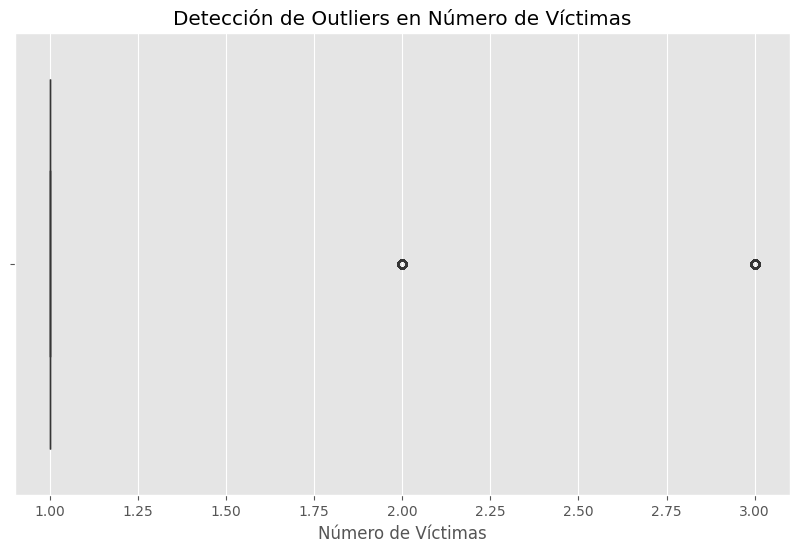

In [ ]:

print("ANÁLISIS DE OUTLIERS:")

victimas = df_clean['Total de Víctimas del Caso']

# Mét. IQR para outliers
Q1 = victimas.quantile(0.25)
Q3 = victimas.quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = victimas[(victimas < limite_inferior) | (victimas > limite_superior)]
print(f"Número de outliers en 'Total de Víctimas del Caso': {len(outliers)}")
print(f"Porcentaje de outliers: {len(outliers)/len(victimas)*100:.2f}%")

plt.figure(figsize=(10, 6))
sns.boxplot(x=victimas)
plt.title('Detección de Outliers en Número de Víctimas')
plt.xlabel('Número de Víctimas')
plt.show()

# En este caso, decidimos mantener los outliers por ser datos reales de conflicto armado pero aplicaremos transformación logarítmica para algunos análisis

ANÁLISIS DE OUTLIERS:


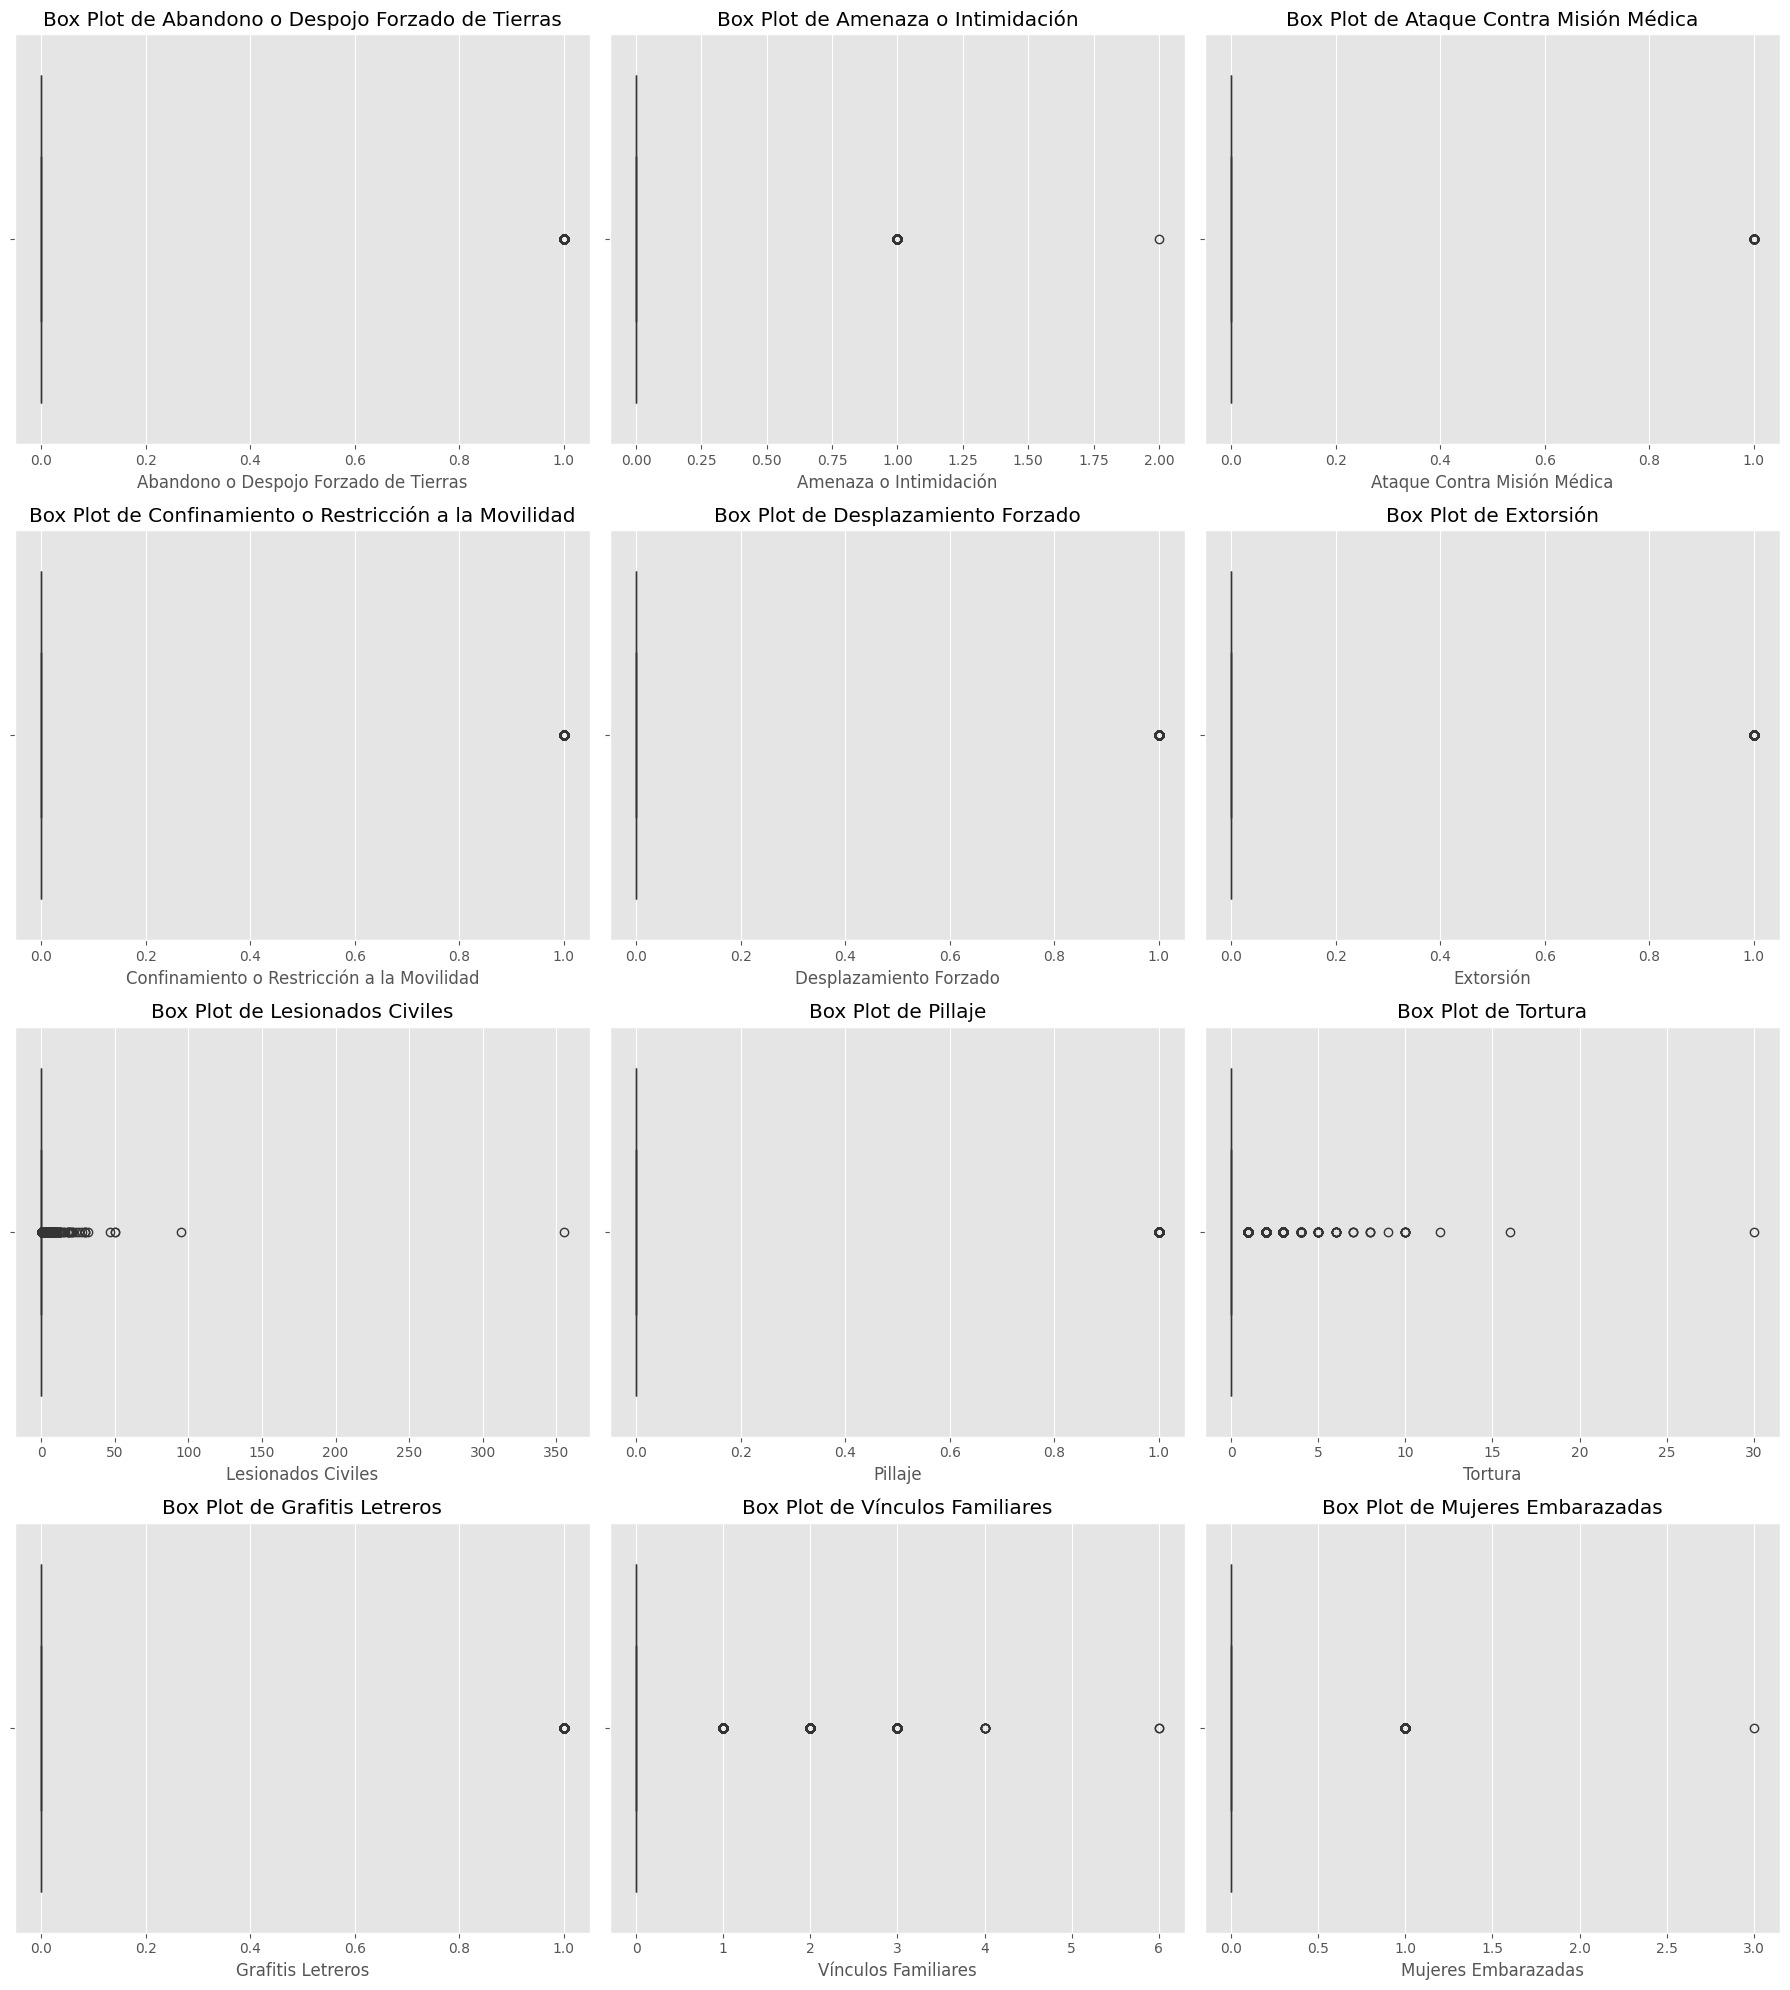


Número de outliers por columna (usando método IQR):
Abandono o Despojo Forzado de Tierras: 4454 outliers
Amenaza o Intimidación: 24375 outliers
Ataque Contra Misión Médica: 60 outliers
Confinamiento o Restricción a la Movilidad: 564 outliers
Desplazamiento Forzado: 14911 outliers
Extorsión: 4887 outliers
Lesionados Civiles: 5932 outliers
Pillaje: 6234 outliers
Tortura: 11223 outliers
Grafitis Letreros: 1731 outliers
Vínculos Familiares: 6546 outliers
Mujeres Embarazadas: 262 outliers


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("ANÁLISIS DE OUTLIERS:")

# Columnas para análisis de outliers
suggested_cols_for_outliers = [
    'Abandono o Despojo Forzado de Tierras',
    'Amenaza o Intimidación',
    'Ataque Contra Misión Médica',
    'Confinamiento o Restricción a la Movilidad',
    'Desplazamiento Forzado',
    'Extorsión',
    'Lesionados Civiles',
    'Pillaje',
    'Tortura',
    'Grafitis Letreros',
    'Vínculos Familiares',
    'Mujeres Embarazadas'
]

# Filtrar las columnas que realmente existen en el DataFrame
cols_to_plot = [col for col in suggested_cols_for_outliers if col in df_clean.columns]

if not cols_to_plot:
    print("Ninguna de las columnas se encontró en el DataFrame.")
else:
    # Crear box plots para cada columna sugerida
    n_cols = 3
    n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
    axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

    for i, col in enumerate(cols_to_plot):
        sns.boxplot(x=df_clean[col], ax=axes[i])
        axes[i].set_title(f'Box Plot de {col}')
        axes[i].set_xlabel(col)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    print("\nNúmero de outliers por columna (usando método IQR):")
    for col in cols_to_plot:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        outliers_count = df_clean[(df_clean[col] < limite_inferior) | (df_clean[col] > limite_superior)].shape[0]
        print(f"{col}: {outliers_count} outliers")

ANÁLISIS TEMPORAL:


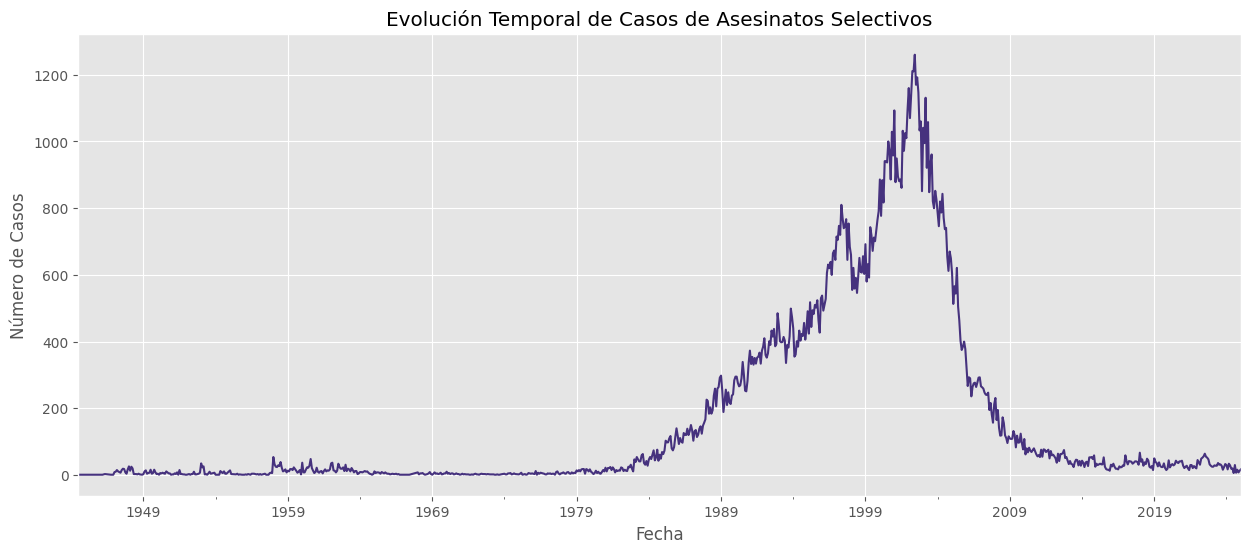

In [ ]:
print("ANÁLISIS TEMPORAL:")

if 'Fecha' in df_clean.columns:
    df_clean['Fecha'] = pd.to_datetime(df_clean['Fecha'])
    df_clean['MesAño'] = df_clean['Fecha'].dt.to_period('M')
    temporal = df_clean.groupby('MesAño').size()

    plt.figure(figsize=(15, 6))
    temporal.plot()
    plt.title('Evolución Temporal de Casos de Asesinatos Selectivos')
    plt.xlabel('Fecha')
    plt.ylabel('Número de Casos')
    plt.grid(True)
    plt.show()

In [ ]:
!pip install "vegafusion[embed]>=1.5.0" vegafusion

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 75.9 MB/s eta 0:00:00


In [ ]:
!pip install "vl-convert-python>=1.6.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.0/33.0 MB 7.8 MB/s eta 0:00:00


In [ ]:
print("ANÁLISIS UNIVARIADO:")

import altair as alt

# Distribución temporal - Casos por año
year_counts = df_clean['Año'].value_counts().sort_index().reset_index()
year_counts.columns = ['Año', 'Número de Casos']
chart_year = alt.Chart(year_counts).mark_bar().encode(
    x=alt.X('Año:O', axis=alt.Axis(title='Año')),
    y=alt.Y('Número de Casos:Q', title='Número de Casos'),
    tooltip=['Año', 'Número de Casos']
).properties(
    title='Distribución de Casos por Año'
).interactive()

# Distribución por mes
meses_orden = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'] # Define 'meses' here
mes_counts = df_clean['Mes'].value_counts().reindex(range(1, 13), fill_value=0).reset_index()
mes_counts.columns = ['Mes_num', 'Número de Casos']
mes_counts['Mes'] = mes_counts['Mes_num'].apply(lambda x: meses[x-1])

chart_month = alt.Chart(mes_counts).mark_bar().encode(
    x=alt.X('Mes:O', sort=meses_orden, axis=alt.Axis(title='Mes')),
    y=alt.Y('Número de Casos:Q', title='Número de Casos'),
    tooltip=['Mes', 'Número de Casos']
).properties(
    title='Distribución de Casos por Mes'
).interactive()

# Distribución por departamento (top 10)
depto_counts = df_clean['Departamento'].value_counts().head(10).reset_index()
depto_counts.columns = ['Departamento', 'Número de Casos']
chart_depto = alt.Chart(depto_counts).mark_bar().encode(
    y=alt.Y('Departamento:O', sort='-x', axis=alt.Axis(title='Departamento')),
    x=alt.X('Número de Casos:Q', title='Número de Casos'),
    tooltip=['Departamento', 'Número de Casos']
).properties(
    title='Top 10 Departamentos por Número de Casos'
).interactive()

# Distribución por presunto responsable
responsable_counts = df_clean['Presunto Responsable'].value_counts().reset_index()
responsable_counts.columns = ['Presunto Responsable', 'Número de Casos']
chart_responsable = alt.Chart(responsable_counts).mark_bar().encode(
    x=alt.X('Presunto Responsable:O', axis=alt.Axis(title='Grupo Armado')),
    y=alt.Y('Número de Casos:Q', title='Número de Casos'),
    tooltip=['Presunto Responsable', 'Número de Casos']
).properties(
    title='Distribución por Presunto Responsable'
).interactive()

# Combinar gráficos univariados
chart_univariado_top = alt.vconcat(alt.hconcat(chart_year, chart_month), alt.hconcat(chart_depto, chart_responsable))
chart_univariado_top.display()


# Distribución de número de víctimas
victimas_counts = df_clean['Total de Víctimas del Caso'].value_counts().reset_index()
victimas_counts.columns = ['Número de Víctimas', 'Frecuencia']
chart_victimas = alt.Chart(victimas_counts).mark_bar().encode(
    x=alt.X('Número de Víctimas:O', axis=alt.Axis(title='Número de Víctimas')),
    y=alt.Y('Frecuencia:Q', title='Frecuencia'),
    tooltip=['Número de Víctimas', 'Frecuencia']
).properties(
    title='Distribución de Número de Víctimas por Caso'
).interactive()

# Distribución logarítmica de víctimas (requiere un histograma, no un recuento de valores únicos)
# Para un histograma con Altair, necesitamos los datos originales
chart_log_victimas = alt.Chart(df_clean).mark_bar().encode(
    alt.X('Total de Víctimas del Caso', bin=alt.Bin(maxbins=30), title='log(Número de Víctimas + 1)'),
    y=alt.Y('count()', title='Frecuencia'),
    tooltip=[alt.Tooltip('Total de Víctimas del Caso', bin=alt.Bin(maxbins=30), title='Rango de Víctimas'), 'count()']
).transform_calculate(
    'Total de Víctimas del Caso', 'log(datum["Total de Víctimas del Caso"] + 1)'
).properties(
    title='Distribución Logarítmica de Víctimas por Caso'
).interactive()


chart_univariado_bottom = alt.hconcat(chart_victimas, chart_log_victimas)
chart_univariado_bottom.display()

ANÁLISIS UNIVARIADO:


alt.VConcatChart(...)

alt.HConcatChart(...)

ANÁLISIS BIVARIADO:


alt.Chart(...)

alt.Chart(...)

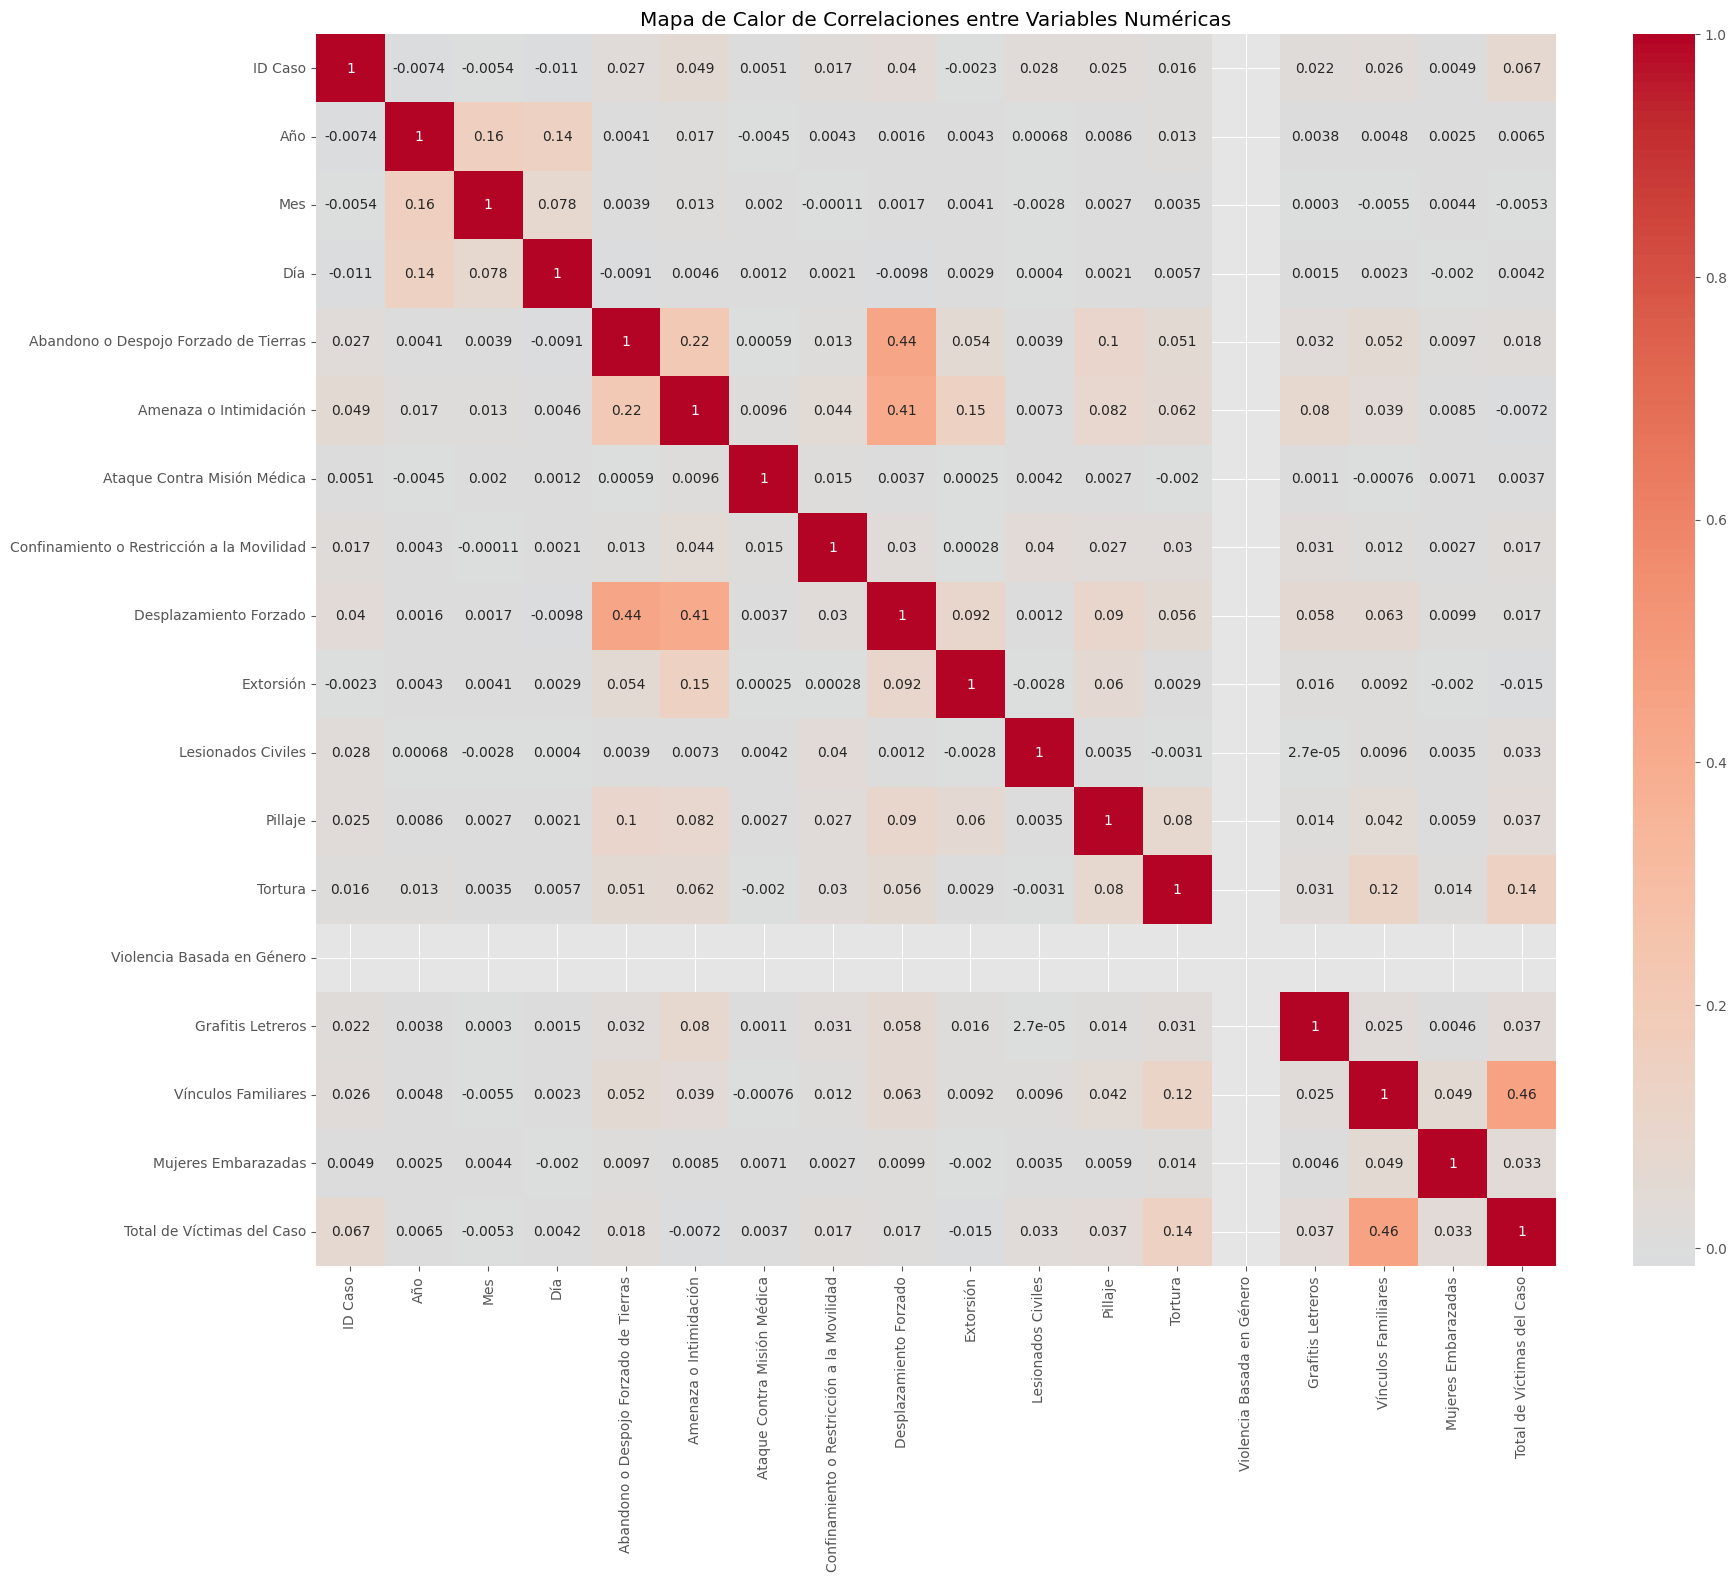

alt.Chart(...)

Análisis de violencia de género:
Violencia Basada en Género: 0.0 casos
Mujeres Embarazadas: 264 casos


In [ ]:
print("ANÁLISIS BIVARIADO:")

import altair as alt
import pandas as pd
import seaborn as sns # Keep seaborn for heatmap if needed
import matplotlib.pyplot as plt # Keep matplotlib for heatmap if needed


# Relación entre año y número de víctimas
victimas_por_año = df_clean.groupby('Año')['Total de Víctimas del Caso'].sum().reset_index()
victimas_por_año.columns = ['Año', 'Total de Víctimas']
chart_victimas_año = alt.Chart(victimas_por_año).mark_bar().encode(
    x=alt.X('Año:O', axis=alt.Axis(title='Año')),
    y=alt.Y('Total de Víctimas:Q', title='Total de Víctimas'),
    tooltip=['Año', 'Total de Víctimas']
).properties(
    title='Total de Víctimas por Año'
).interactive()
chart_victimas_año.display()


# Presunto responsable vs número de víctimas
victimas_por_responsable = df_clean.groupby('Presunto Responsable')['Total de Víctimas del Caso'].sum().sort_values(ascending=False).reset_index()
victimas_por_responsable.columns = ['Presunto Responsable', 'Total de Víctimas']
chart_victimas_responsable = alt.Chart(victimas_por_responsable).mark_bar().encode(
    x=alt.X('Presunto Responsable:O', axis=alt.Axis(title='Presunto Responsable')),
    y=alt.Y('Total de Víctimas:Q', title='Total de Víctimas'),
    tooltip=['Presunto Responsable', 'Total de Víctimas']
).properties(
    title='Total de Víctimas por Presunto Responsable'
).interactive()
chart_victimas_responsable.display()


# Heatmap de correlación para variables numéricas
# Keeping matplotlib/seaborn for heatmap as Altair is not ideal for this type of correlation matrix heatmap
numeric_df = df_clean.select_dtypes(include=[np.number])
numeric_df = numeric_df.drop(['Latitud', 'Longitud'], axis=1, errors='ignore')

plt.figure(figsize=(20, 16))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Mapa de Calor de Correlaciones entre Variables Numéricas')
plt.show()


# Cruzar presunto responsable con modalidad
ct = pd.crosstab(df_clean['Presunto Responsable'], df_clean['Modalidad']).stack().reset_index()
ct.columns = ['Presunto Responsable', 'Modalidad', 'Número de Casos']

chart_crosstab = alt.Chart(ct).mark_rect().encode(
    x=alt.X('Modalidad:O', axis=alt.Axis(title='Modalidad')),
    y=alt.Y('Presunto Responsable:O', axis=alt.Axis(title='Presunto Responsable')),
    color=alt.Color('Número de Casos:Q', legend=alt.Legend(title="Número de Casos")),
    tooltip=['Presunto Responsable', 'Modalidad', 'Número de Casos']
).properties(
    title='Relación entre Presunto Responsable y Modalidad'
).interactive()
chart_crosstab.display()


# Analizar la violencia por género
# Sumar todas las columnas de violencia de género (si existen múltiples)
violencia_genero_cols = [col for col in df_clean.columns if 'Género' in col or 'Mujeres' in col]
if violencia_genero_cols:
    print("Análisis de violencia de género:")
    for col in violencia_genero_cols:
        if col in df_clean.columns:
            # Convert to numeric, coercing errors, and fill NaN with 0 before summing
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)
            print(f"{col}: {df_clean[col].sum()} casos")

###H1

HIPÓTESIS 1: Grupos paramilitares como principales responsables
Número de casos por presunto responsable:
Presunto Responsable
GRUPO PARAMILITAR                               65997
DESCONOCIDO                                     31756
GUERRILLA                                       24068
GRUPO ARMADO NO IDENTIFICADO                    22368
AGENTE DEL ESTADO                                4917
GRUPO POSDESMOVILIZACIÓN                         4130
BANDOLERISMO                                     1641
OTRO ¿CUÁL?                                      1515
AGENTE DEL ESTADO - GRUPO PARAMILITAR             559
CRIMEN ORGANIZADO                                 148
AGENTE DEL ESTADO - GRUPO POSDESMOVILIZACIÓN       24
AGENTE EXTRANJERO                                  11
GRUPO POSDESMOVILIZACIÓN - GUERRILLA                2
Name: count, dtype: int64

Total de víctimas por presunto responsable:
Presunto Responsable
GRUPO PARAMILITAR                               77835
DESCONOCIDO              

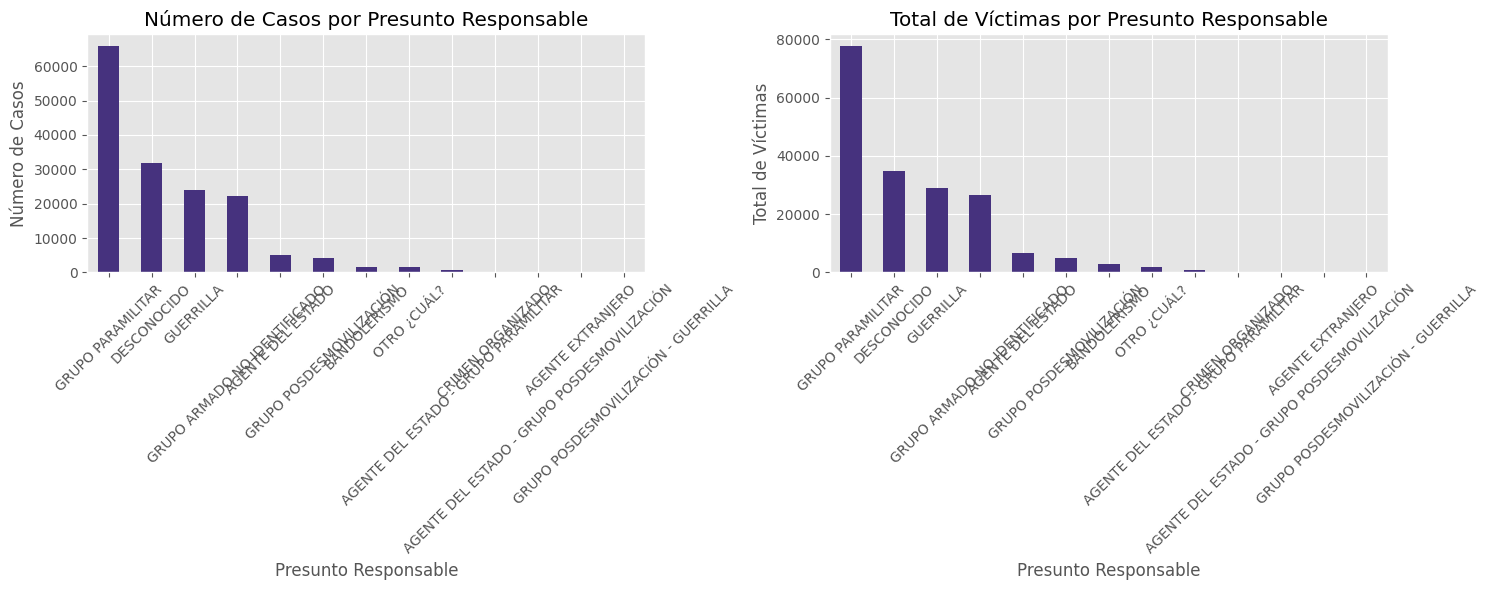


Prueba chi-cuadrado: χ² = 4022.758, p = 0.000
Los paramilitares tienen una proporción significativamente diferente del 50% de los casos


In [ ]:
# HIPÓTESIS 1: Los grupos paramilitares son los principales responsables de asesinatos selectivos
print("HIPÓTESIS 1: Grupos paramilitares como principales responsables")

# Análisis cuantitativo
responsable_counts = df_clean['Presunto Responsable'].value_counts()
responsable_victimas = df_clean.groupby('Presunto Responsable')['Total de Víctimas del Caso'].sum().sort_values(ascending=False)

print("Número de casos por presunto responsable:")
print(responsable_counts)
print("\nTotal de víctimas por presunto responsable:")
print(responsable_victimas)

# Calcular porcentajes
total_casos = len(df_clean)
total_victimas = df_clean['Total de Víctimas del Caso'].sum()

paramilitares_casos = responsable_counts.get('GRUPO PARAMILITAR', 0)
paramilitares_victimas = responsable_victimas.get('GRUPO PARAMILITAR', 0)

print(f"\nPorcentaje de casos atribuidos a paramilitares: {paramilitares_casos/total_casos*100:.2f}%")
print(f"Porcentaje de víctimas atribuidas a paramilitares: {paramilitares_victimas/total_victimas*100:.2f}%")

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de casos
responsable_counts.plot(kind='bar', ax=ax1)
ax1.set_title('Número de Casos por Presunto Responsable')
ax1.set_ylabel('Número de Casos')
ax1.tick_params(axis='x', rotation=45)

# Gráfico de víctimas
responsable_victimas.plot(kind='bar', ax=ax2)
ax2.set_title('Total de Víctimas por Presunto Responsable')
ax2.set_ylabel('Total de Víctimas')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Prueba estadística (chi-cuadrado para proporciones)
observed = [paramilitares_casos, total_casos - paramilitares_casos]
expected = [total_casos * 0.5, total_casos * 0.5]  # Hipótesis nula: 50% de los casos
chi2, p = stats.chisquare(observed, f_exp=expected)

print(f"\nPrueba chi-cuadrado: χ² = {chi2:.3f}, p = {p:.3f}")
if p < 0.05:
    print("Los paramilitares tienen una proporción significativamente diferente del 50% de los casos")
else:
    print("No hay evidencia suficiente para afirmar que los paramilitares tienen una proporción diferente del 50%")

### H2

HIPÓTESIS 2: Tendencia temporal en los asesinatos
Tendencia lineal: Pendiente = 46.714 (casos por año)
Coeficiente de determinación R² = 0.117
Valor p de la tendencia = 0.002


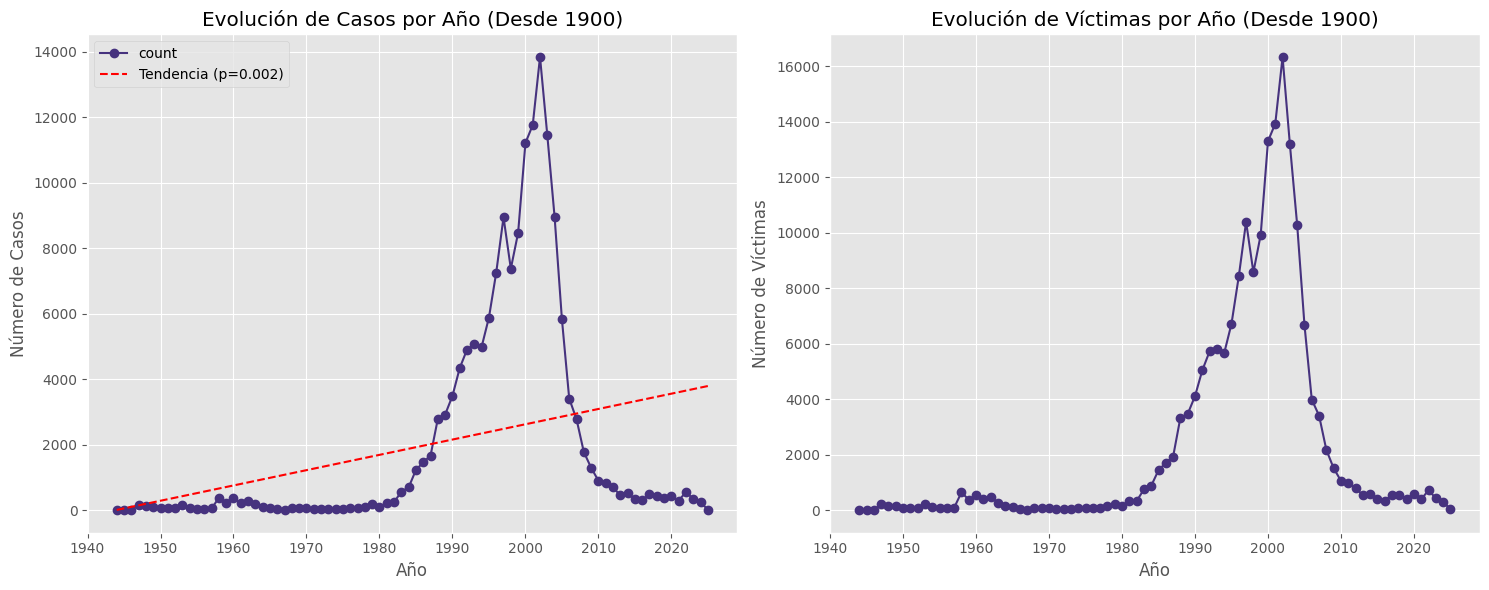

In [ ]:
# HIPÓTESIS 2: Existe una tendencia temporal en los asesinatos

print("HIPÓTESIS 2: Tendencia temporal en los asesinatos")

# Filter data to exclude years before 1900
df_filtered = df_clean[df_clean['Año'] >= 1900].copy()

# Agrupar por año
casos_por_año = df_filtered['Año'].value_counts().sort_index()
victimas_por_año = df_filtered.groupby('Año')['Total de Víctimas del Caso'].sum()

# Calcular tendencia (regresión lineal)
x = casos_por_año.index.values
y = casos_por_año.values
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Tendencia lineal: Pendiente = {slope:.3f} (casos por año)")
print(f"Coeficiente de determinación R² = {r_value**2:.3f}")
print(f"Valor p de la tendencia = {p_value:.3f}")

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de casos por año
casos_por_año.plot(kind='line', marker='o', ax=ax1)
ax1.set_title('Evolución de Casos por Año (Desde 1900)')
ax1.set_xlabel('Año')
ax1.set_ylabel('Número de Casos')
ax1.grid(True)

# Añadir línea de tendencia
ax1.plot(x, intercept + slope*x, 'r--', label=f'Tendencia (p={p_value:.3f})')
ax1.legend()

# Gráfico de víctimas por año
victimas_por_año.plot(kind='line', marker='o', ax=ax2)
ax2.set_title('Evolución de Víctimas por Año (Desde 1900)')
ax2.set_xlabel('Año')
ax2.set_ylabel('Número de Víctimas')
ax2.grid(True)

plt.tight_layout()
plt.show()

### H3

In [ ]:
# HIPÓTESIS 3: Ciertas regiones tienen mayor incidencia
print("HIPÓTESIS 3: Regiones con mayor incidencia")

import altair as alt
import pandas as pd
import numpy as np
from scipy import stats

# Análisis por departamento
departamento_counts = df_clean['Departamento'].value_counts().reset_index()
departamento_counts.columns = ['Departamento', 'Número de Casos']
departamento_victimas = df_clean.groupby('Departamento')['Total de Víctimas del Caso'].sum().sort_values(ascending=False).reset_index()
departamento_victimas.columns = ['Departamento', 'Total de Víctimas']


print("Top 10 departamentos por número de casos:")
print(departamento_counts.head(10))
print("\nTop 10 departamentos por número de víctimas:")
print(departamento_victimas.head(10))

# Calcular tasas (si tenemos datos de población sería mejor)
total_casos = len(df_clean)
total_victimas = df_clean['Total de Víctimas del Caso'].sum()

# Ensure 'ANTIOQUIA' is in the index before accessing
top_5_casos_deptos = departamento_counts.head(5)['Departamento'].tolist()
top_5_casos = departamento_counts[departamento_counts['Departamento'].isin(top_5_casos_deptos)]['Número de Casos'].sum() / total_casos * 100

top_5_victimas_deptos = departamento_victimas.head(5)['Departamento'].tolist()
top_5_victimas = departamento_victimas[departamento_victimas['Departamento'].isin(top_5_victimas_deptos)]['Total de Víctimas'].sum() / total_victimas * 100


print(f"\nLos 5 departamentos con más casos concentran el {top_5_casos:.2f}% de todos los casos")
print(f"Los 5 departamentos con más víctimas concentran el {top_5_victimas:.2f}% de todas las víctimas")

# Prueba de concentración (índice de Gini simplificado)
def gini_coefficient(x):
    # Ordenar y calcular el índice de Gini
    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * x)) / (n * np.sum(x))

gini_casos = gini_coefficient(departamento_counts['Número de Casos'].values)
gini_victimas = gini_coefficient(departamento_victimas['Total de Víctimas'].values)

print(f"\nÍndice de Gini para concentración de casos: {gini_casos:.3f}")
print(f"Índice de Gini para concentración de víctimas: {gini_victimas:.3f}")

# Visualización con Altair
chart_casos_depto = alt.Chart(departamento_counts.head(15)).mark_bar().encode(
    y=alt.Y('Departamento:O', sort='-x', axis=alt.Axis(title='Departamento')),
    x=alt.X('Número de Casos:Q', title='Número de Casos'),
    tooltip=['Departamento', 'Número de Casos']
).properties(
    title='Top 15 Departamentos por Número de Casos'
).interactive()

chart_victimas_depto = alt.Chart(departamento_victimas.head(15)).mark_bar().encode(
    y=alt.Y('Departamento:O', sort='-x', axis=alt.Axis(title='Departamento')),
    x=alt.X('Total de Víctimas:Q', title='Número de Víctimas'),
    tooltip=['Departamento', 'Total de Víctimas']
).properties(
    title='Top 15 Departamentos por Número de Víctimas'
).interactive()

alt.hconcat(chart_casos_depto, chart_victimas_depto).display()

HIPÓTESIS 3: Regiones con mayor incidencia
Top 10 departamentos por número de casos:
         Departamento  Número de Casos
0           ANTIOQUIA            55334
1           SANTANDER             8265
2  NORTE DE SANTANDER             8138
3               CESAR             7732
4           MAGDALENA             7653
5     VALLE DEL CAUCA             7380
6                META             5196
7               CAUCA             4671
8              TOLIMA             4649
9             CAQUETA             4518

Top 10 departamentos por número de víctimas:
         Departamento  Total de Víctimas
0           ANTIOQUIA              63542
1           SANTANDER               9899
2  NORTE DE SANTANDER               9795
3               CESAR               9241
4           MAGDALENA               9128
5     VALLE DEL CAUCA               8544
6                META               6277
7              TOLIMA               5747
8               CAUCA               5695
9             CAQUETA         

alt.HConcatChart(...)

### H4

In [ ]:
import altair as alt

alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

HIPÓTESIS 4: Relación entre tipo de arma y presunto responsable
Prueba chi-cuadrado de independencia: χ² = 4350.175, p = 0.000, gl = 444
Hay una relación significativa entre el tipo de arma y el presunto responsable


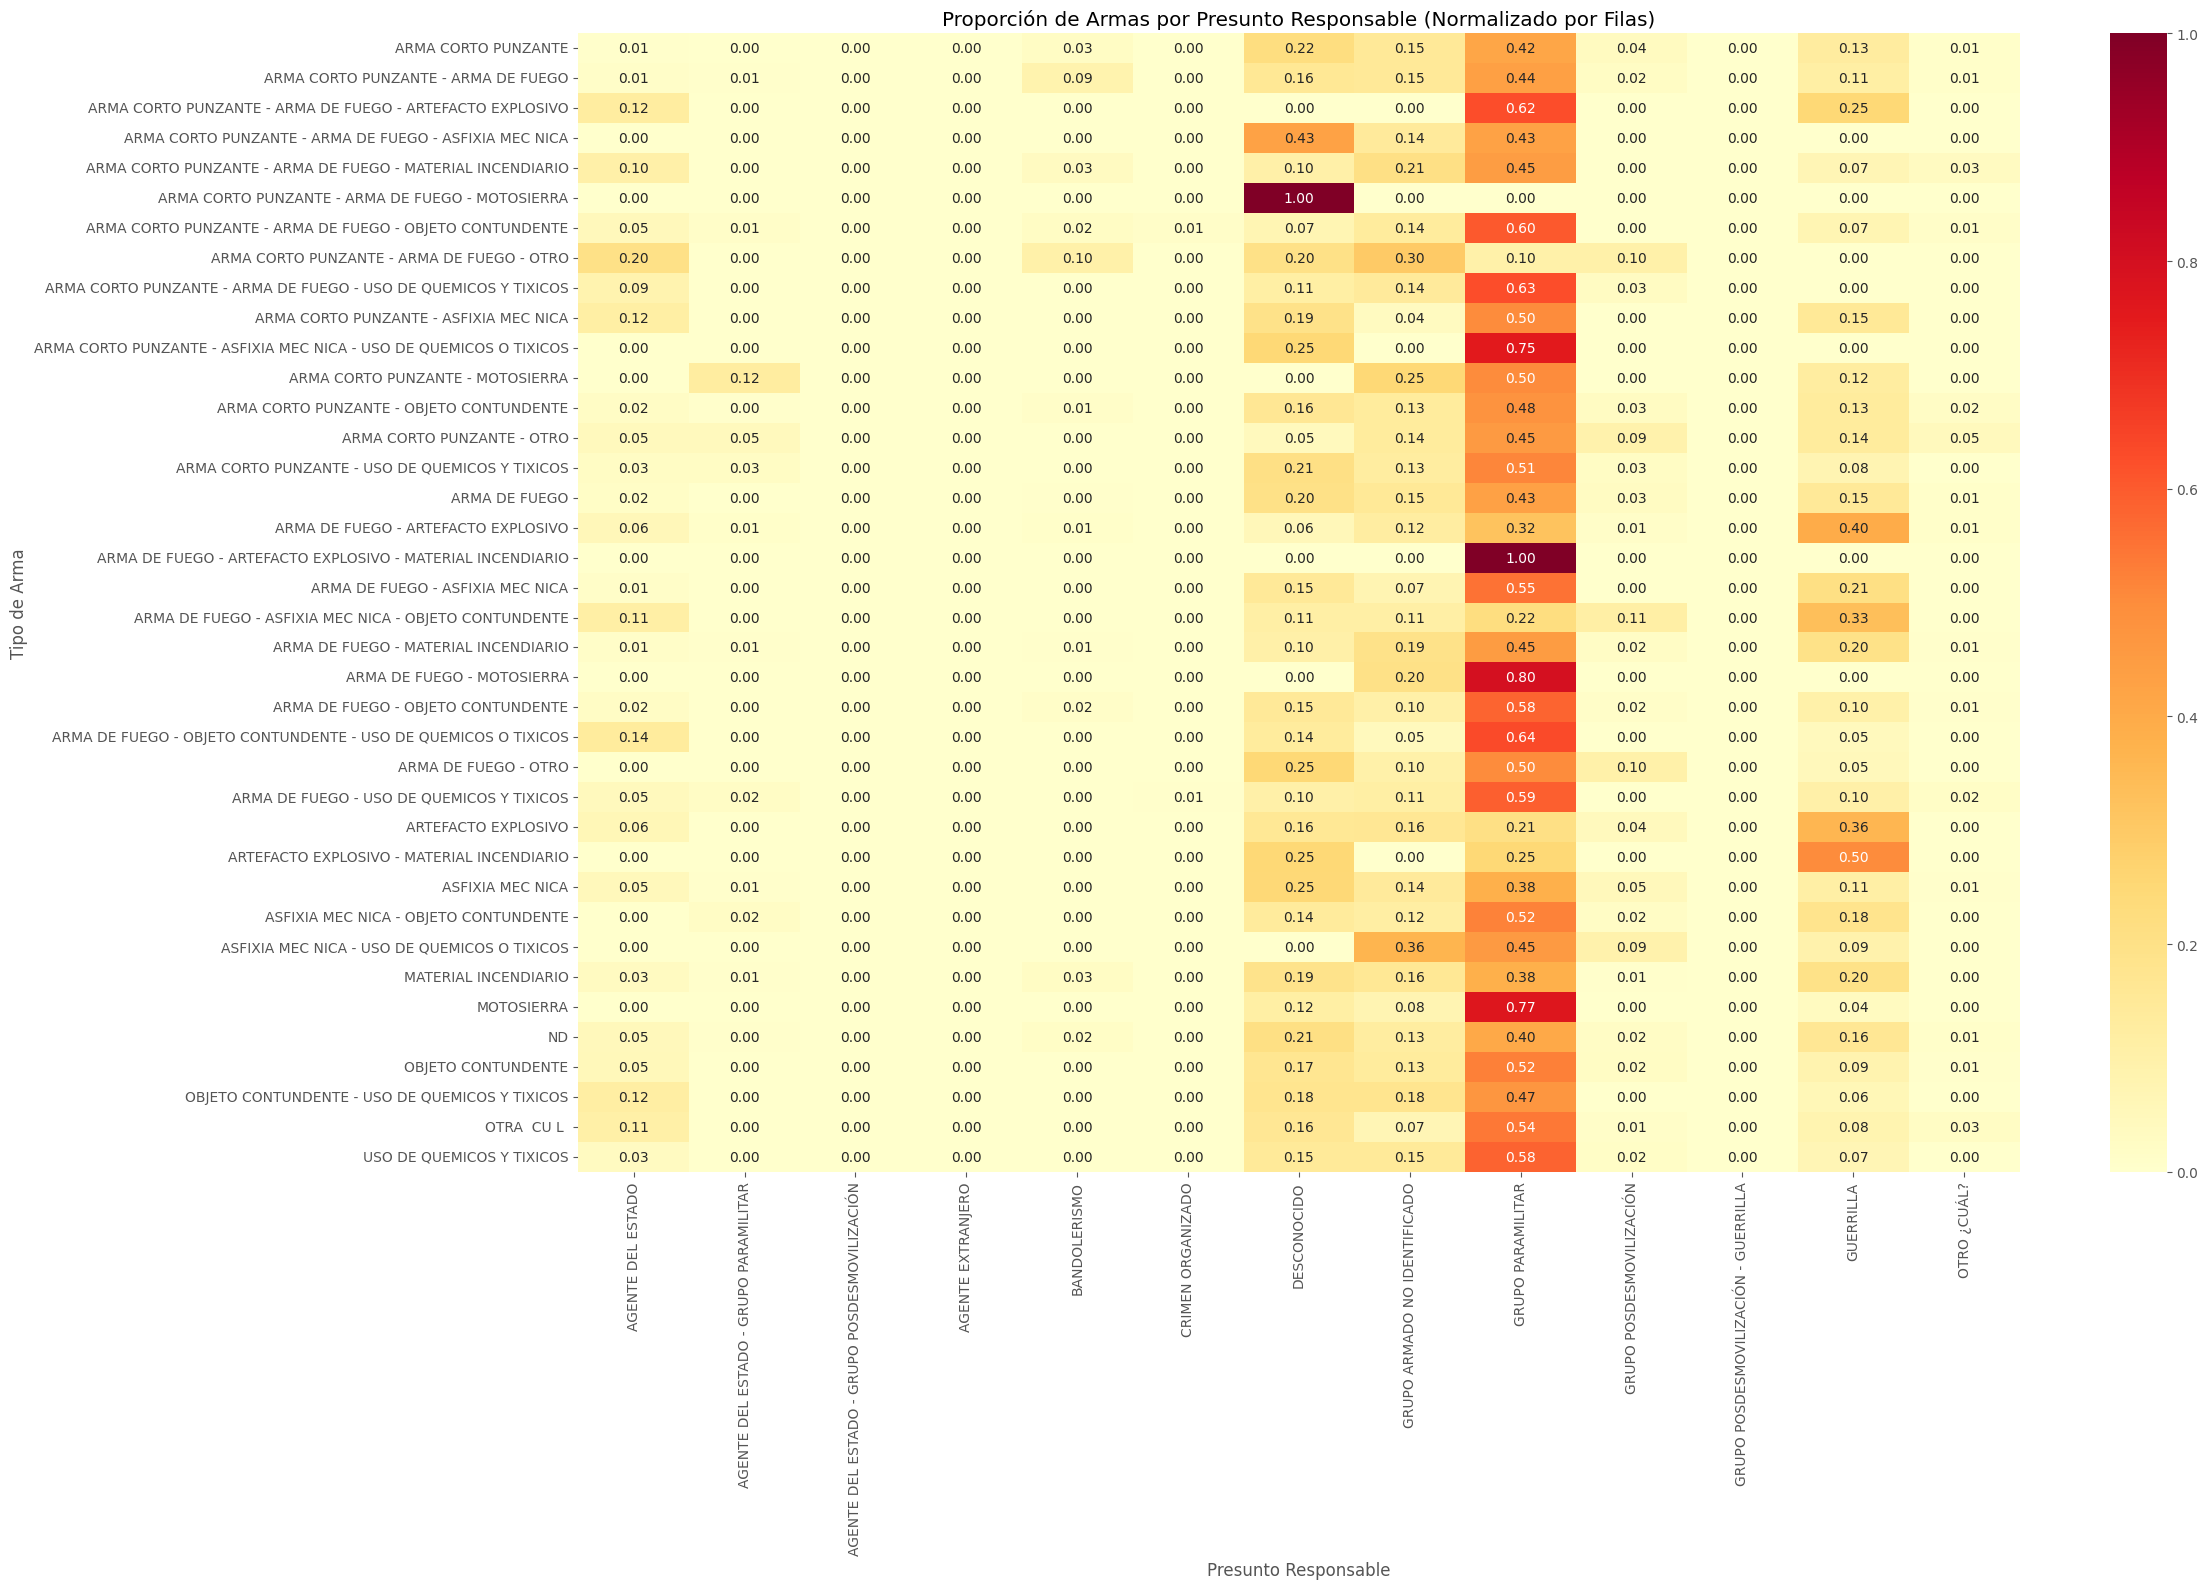

In [ ]:
# HIPÓTESIS 4: Correlación entre tipo de arma y presunto responsable
print("HIPÓTESIS 4: Relación entre tipo de arma y presunto responsable")

# Crear tabla cruzada
arma_responsable = pd.crosstab(df_clean['Tipo de Armas'], df_clean['Presunto Responsable'])

# Prueba chi-cuadrado de independencia
chi2, p, dof, expected = stats.chi2_contingency(arma_responsable)

print(f"Prueba chi-cuadrado de independencia: χ² = {chi2:.3f}, p = {p:.3f}, gl = {dof}")
if p < 0.05:
    print("Hay una relación significativa entre el tipo de arma y el presunto responsable")
else:
    print("No hay evidencia de relación entre el tipo de arma y el presunto responsable")

# Visualización de la tabla cruzada (normalizada por filas para mejor interpretación)
arma_responsable_norm = arma_responsable.div(arma_responsable.sum(axis=1), axis=0)

plt.figure(figsize=(24, 16))
sns.heatmap(arma_responsable_norm, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Proporción de Armas por Presunto Responsable (Normalizado por Filas)')
plt.xlabel('Presunto Responsable')
plt.ylabel('Tipo de Arma')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### H6


HIPÓTESIS 6: Múltiples víctimas y tipo de actor armado
Prueba chi-cuadrado: χ² = 3629.071, p = 0.000, gl = 12
Hay una relación significativa entre múltiples víctimas y el tipo de actor armado

Proporción de casos con múltiples víctimas por actor armado:
Presunto Responsable
BANDOLERISMO                                    0.482023
AGENTE DEL ESTADO - GRUPO POSDESMOVILIZACIÓN    0.333333
AGENTE DEL ESTADO                               0.293878
AGENTE EXTRANJERO                               0.272727
AGENTE DEL ESTADO - GRUPO PARAMILITAR           0.232558
GUERRILLA                                       0.162706
GRUPO POSDESMOVILIZACIÓN                        0.145763
GRUPO ARMADO NO IDENTIFICADO                    0.145252
GRUPO PARAMILITAR                               0.145249
CRIMEN ORGANIZADO                               0.101351
OTRO ¿CUÁL?                                     0.097690
DESCONOCIDO                                     0.080268
GRUPO POSDESMOVILIZACIÓN - GUERRILLA    

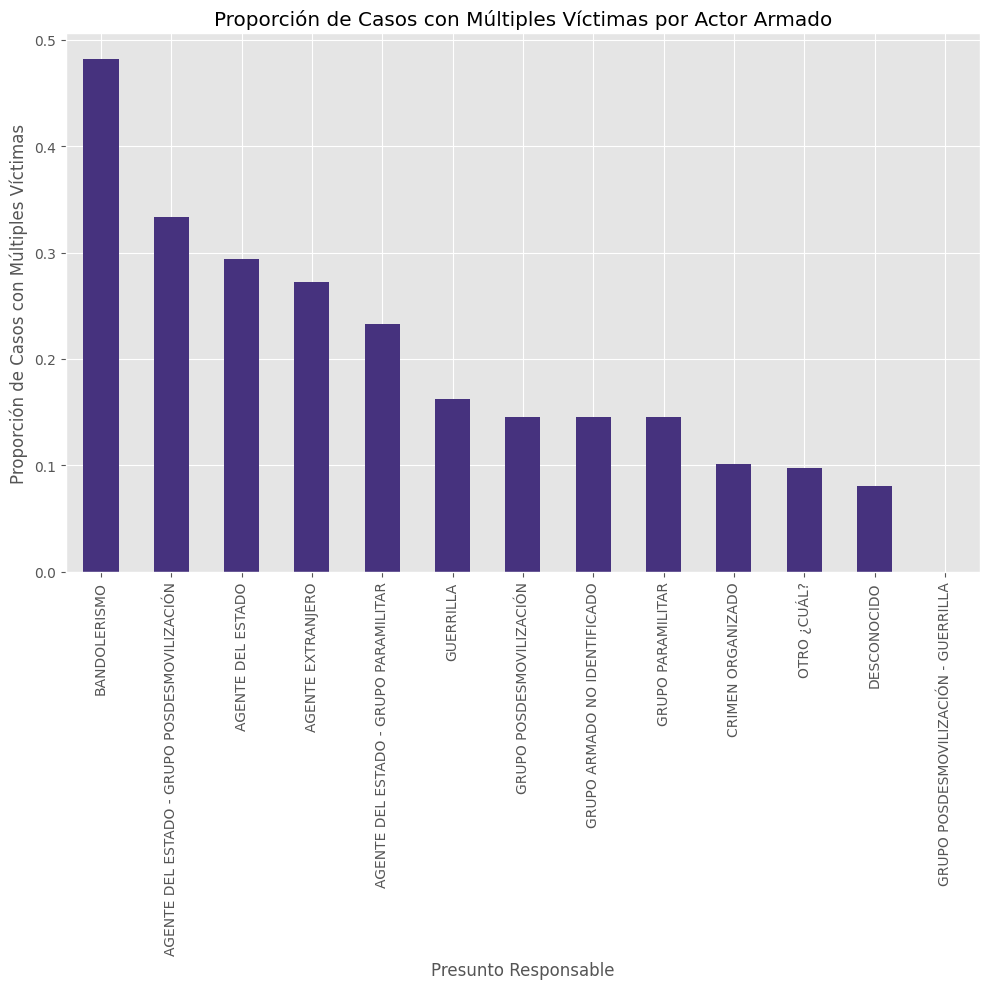

In [ ]:
# HIPÓTESIS 6: Relación entre múltiples víctimas y tipo de actor armado
print("\n" + "=" * 50)
print("HIPÓTESIS 6: Múltiples víctimas y tipo de actor armado")
print("=" * 50)

# Crear variable binaria para múltiples víctimas
df_clean['Multiples_Victimas'] = df_clean['Total de Víctimas del Caso'] > 1

# Tabla cruzada
multiples_responsable = pd.crosstab(df_clean['Multiples_Victimas'], df_clean['Presunto Responsable'])

# Prueba chi-cuadrado
chi2_multi, p_multi, dof_multi, expected_multi = stats.chi2_contingency(multiples_responsable)

print(f"Prueba chi-cuadrado: χ² = {chi2_multi:.3f}, p = {p_multi:.3f}, gl = {dof_multi}")
if p_multi < 0.05:
    print("Hay una relación significativa entre múltiples víctimas y el tipo de actor armado")
else:
    print("No hay evidencia de relación entre múltiples víctimas y el tipo de actor armado")

# Calcular proporciones
prop_multiples = multiples_responsable.div(multiples_responsable.sum(axis=0), axis=1)
print("\nProporción de casos con múltiples víctimas por actor armado:")
print(prop_multiples.loc[True].sort_values(ascending=False))

# Visualización
plt.figure(figsize=(10, 10))
prop_multiples.loc[True].sort_values(ascending=False).plot(kind='bar')
plt.title('Proporción de Casos con Múltiples Víctimas por Actor Armado')
plt.ylabel('Proporción de Casos con Múltiples Víctimas')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Análisis espacial


In [ ]:
print("ANÁLISIS ESPACIAL")

# Instalar librerías necesarias para análisis espacial
!pip install geopandas folium geopy contextily
!apt install libspatialindex-dev

import geopandas as gpd
import folium
from folium import plugins
from geopy.geocoders import Nominatim
from shapely.geometry import Point
import contextily as ctx
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Verificar y limpiar datos espaciales
print("Verificación de datos espaciales:")
print(f"Valores nulos en Latitud: {df_clean['Latitud'].isnull().sum()}")
print(f"Valores nulos en Longitud: {df_clean['Longitud'].isnull().sum()}")

# Eliminar filas con coordenadas nulas o inválidas
df_spatial = df_clean.dropna(subset=['Latitud', 'Longitud']).copy()
df_spatial = df_spatial[(df_spatial['Latitud'] != 0) & (df_spatial['Longitud'] != 0)]

print(f"Casos con coordenadas válidas: {len(df_spatial)}/{len(df_clean)}")

ANÁLISIS ESPACIAL
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 52.5 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libspatialindex-c6 libspatialindex6
The following NEW packages will be installed:
  libspatialindex-c6 libspatialindex-dev libspatialindex6
0 upgraded, 3 newly installed, 0 to remove and 41 not upgraded.
Need to get 319 kB of archives.
After this operation, 1,416 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libspatialindex6 amd64 1.9.3-2 [247 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libspatialindex-c6 amd64 1.9.3-2 [55.8 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libspatialindex-dev amd64 1.9.3-2 [16.0 kB]
Fetched 319 kB in 1s (258 kB/s)
Selecting previously unselected package libspatialindex6:amd64.
(Reading database ... 125082 files and dir

In [ ]:
# 1. MAPA DE CALOR DE DENSIDAD
print("\n1. Mapa de calor de densidad")

# Crear mapa base centrado en Colombia
colombia_center = [4.5709, -74.2973]
m = folium.Map(location=colombia_center, zoom_start=6, tiles='OpenStreetMap')

# Añadir points of events (omitted for performance with large dataset)
# for idx, row in df_spatial.iterrows():
#     folium.CircleMarker(
#         location=[row['Latitud'], row['Longitud']],
#         radius=3,
#         color='red',
#         fill=True,
#         fillColor='red',
#         fillOpacity=0.7,
#         popup=f"{row['Municipio']} - {row['Año']}"
#     ).add_to(m)

# Añadir mapa de calor
heat_data = [[row['Latitud'], row['Longitud']] for idx, row in df_spatial.iterrows()]
plugins.HeatMap(heat_data, radius=15).add_to(m)

# Añadir controles de capas
folium.LayerControl().add_to(m)

print("Mapa de calor created. Showing...")
m.save('heatmap.html')
display(m)


1. Mapa de calor de densidad
Mapa de calor created. Showing...



5. Análisis de proximidad a capitales departamentales


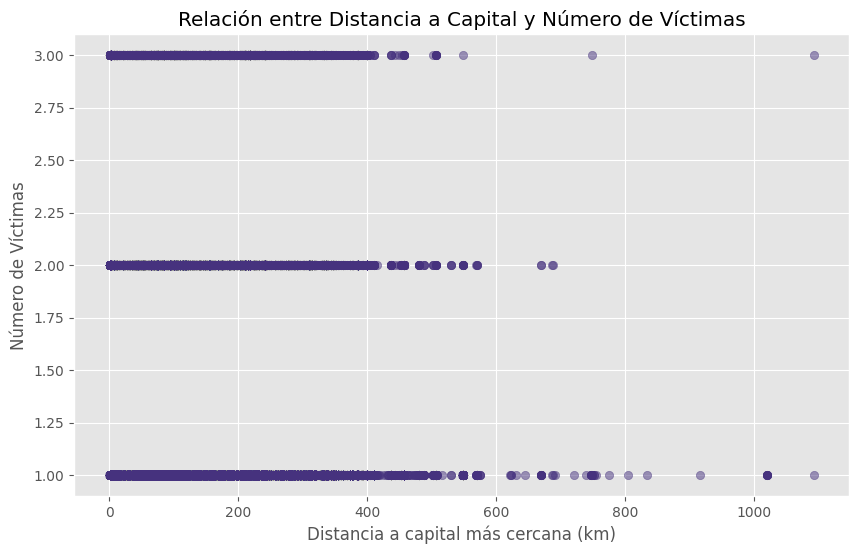

Correlación entre distancia a capital y número de víctimas: 0.025

6. Mapa coroplético de densidad de casos
No se pudo crear el mapa coroplético: name 'url' is not defined


In [ ]:
# 2. ANÁLISIS DE DISTANCIA A CAPITALES
print("\n5. Análisis de proximidad a capitales departamentales")

# Lista de capitales departamentales y sus coordenadas (aproximadas)
capitales = {
    'BOGOTÁ': [4.7110, -74.0721],
    'MEDELLÍN': [6.2442, -75.5812],
    'CALI': [3.4516, -76.5320],
    'BARRANQUILLA': [10.9639, -74.7964],
    'CARTAGENA': [10.3910, -75.4794],
    # Añadir más capitales según sea necesario
}

def calcular_distancia(lat1, lon1, lat2, lon2):
    # Fórmula haversine para calcular distancia entre dos puntos
    from math import radians, sin, cos, sqrt, atan2

    R = 6371  # Radio de la Tierra en km

    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

# Calcular distancia a la capital más cercana
distancias = []
for idx, row in df_spatial.iterrows():
    min_dist = float('inf')
    for capital, coords in capitales.items():
        dist = calcular_distancia(row['Latitud'], row['Longitud'], coords[0], coords[1])
        if dist < min_dist:
            min_dist = dist
    distancias.append(min_dist)

df_spatial['Distancia_Capital'] = distancias

# Analizar relación entre distancia a capital y número de víctimas
plt.figure(figsize=(10, 6))
plt.scatter(df_spatial['Distancia_Capital'], df_spatial['Total de Víctimas del Caso'], alpha=0.5)
plt.title('Relación entre Distancia a Capital y Número de Víctimas')
plt.xlabel('Distancia a capital más cercana (km)')
plt.ylabel('Número de Víctimas')
plt.grid(True)
plt.show()

# Calcular correlación
correlacion = df_spatial['Distancia_Capital'].corr(df_spatial['Total de Víctimas del Caso'])
print(f"Correlación entre distancia a capital y número de víctimas: {correlacion:.3f}")

# 6. MAPA COROPLÉTICO (si tenemos los datos geoespaciales)
print("\n6. Mapa coroplético de densidad de casos")

try:
    # Agrupar casos por departamento
    casos_por_depto = df_spatial['Departamento'].value_counts().reset_index()
    casos_por_depto.columns = ['NOMBRE_DPT', 'Casos']

    # Crear mapa coroplético básico
    m_coropletico = folium.Map(location=colombia_center, zoom_start=6)

    # Añadir datos coropléticos (esto es un ejemplo, necesitaríamos el GeoJSON adecuado)
    folium.Choropleth(
        geo_data=url,
        data=casos_por_depto,
        columns=['NOMBRE_DPT', 'Casos'],
        key_on='feature.properties.NOMBRE_DPT',
        fill_color='YlOrRd',
        fill_opacity=0.7,
        line_opacity=0.2,
        legend_name='Número de casos por departamento'
    ).add_to(m_coropletico)

    print("Mapa coroplético creado. Mostrando...")
    display(m_coropletico)

except Exception as e:
    print(f"No se pudo crear el mapa coroplético: {e}")


7. Análisis de patrones espacio-temporales


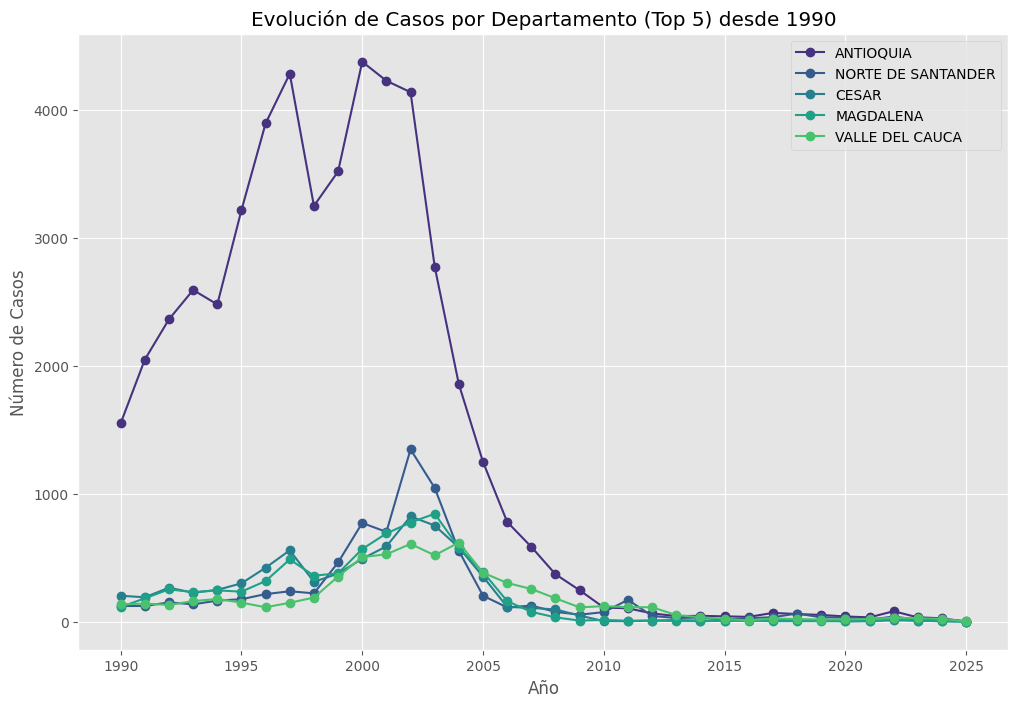

In [ ]:
# 3. ANÁLISIS DE PATRONES ESPACIO-TEMPORALES
print("\n7. Análisis de patrones espacio-temporales")

# Filter data to exclude years before 1990
df_spatial_filtered = df_spatial[df_spatial['Año'] >= 1990].copy()

# Agrupar por año y departamento
espacio_temporal = df_spatial_filtered.groupby(['Año', 'Departamento']).size().unstack(fill_value=0)

# Visualizar evolución por departamento (top 5)
top_deptos = df_spatial_filtered['Departamento'].value_counts().head(5).index
plt.figure(figsize=(12, 8))

for depto in top_deptos:
    if depto in espacio_temporal.columns:
        plt.plot(espacio_temporal.index, espacio_temporal[depto], label=depto, marker='o')

plt.title('Evolución de Casos por Departamento (Top 5) desde 1990')
plt.xlabel('Año')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True)
plt.show()

## Análisis estadístico

In [ ]:
!pip install statsmodels scikit-learn pingouin

import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error
import pingouin as pg

# 1. PREPARACIÓN DE DATOS PARA ANÁLISIS AVANZADO
print("1. Preparación de datos para análisis avanzado")

# Seleccionar variables relevantes
variables_numericas = ['Año', 'Mes', 'Día', 'Total de Víctimas del Caso', 'Latitud', 'Longitud']
variables_categoricas = ['Modalidad', 'Presunto Responsable', 'Departamento', 'Tipo de Armas']

# Crear dataset para análisis
df_advanced = df_clean[variables_numericas + variables_categoricas].copy()

# Codificar variables categóricas para análisis
le = LabelEncoder()
for col in variables_categoricas:
    if col in df_advanced.columns:
        df_advanced[col + '_encoded'] = le.fit_transform(df_advanced[col].astype(str))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 6.7 MB/s eta 0:00:00
1. Preparación de datos para análisis avanzado


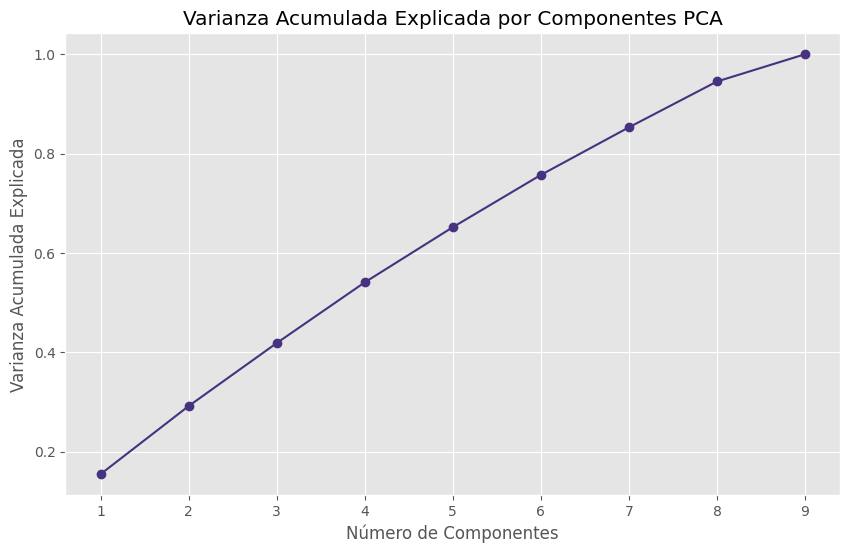

Varianza explicada por los primeros 5 componentes: 65.19%


In [ ]:
# Preparar datos para PCA
pca_vars = ['Año', 'Mes', 'Total de Víctimas del Caso', 'Latitud', 'Longitud'] + \
           [col for col in df_advanced.columns if '_encoded' in col]

pca_df = df_advanced[pca_vars].dropna()

# Estandarizar variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

# Aplicar PCA
pca = PCA(n_components=min(10, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)

# Visualizar varianza explicada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('Varianza Acumulada Explicada por Componentes PCA')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada Explicada')
plt.grid(True)
plt.show()

print(f"Varianza explicada por los primeros 5 componentes: {pca.explained_variance_ratio_[:5].sum()*100:.2f}%")

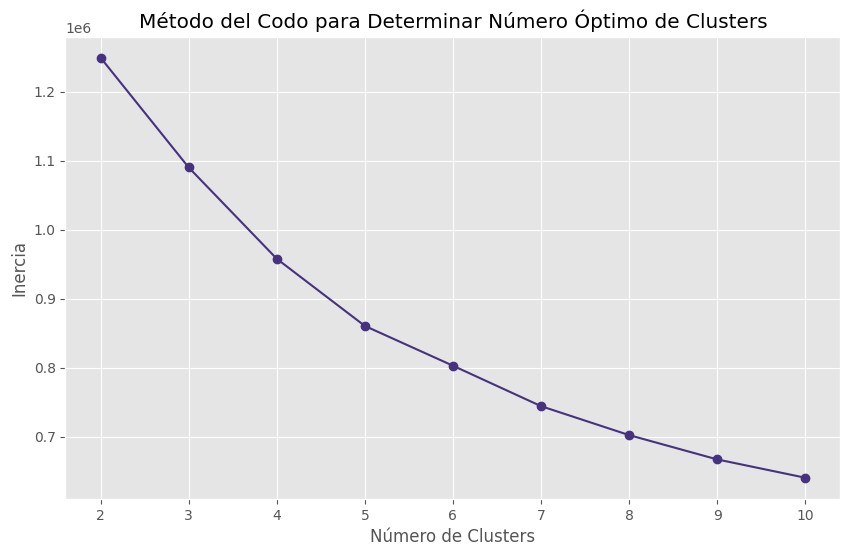


Características promedio por cluster:
                 Año       Mes  Total de Víctimas del Caso   Latitud  \
Cluster                                                                
0        1998.857251  6.369280                    1.204742  8.133815   
1        1997.646475  6.409407                    1.153384  6.880424   
2        1998.822195  6.401103                    1.192817  2.857474   
3           0.000000  0.640297                    1.134550  6.900174   

          Longitud  Modalidad_encoded  Presunto Responsable_encoded  \
Cluster                                                               
0       -73.314435          11.728098                      7.817349   
1       -75.578156          11.910459                      7.537508   
2       -75.971688          11.196529                      7.671805   
3       -74.337965           9.881677                      8.077079   

         Departamento_encoded  Tipo de Armas_encoded  
Cluster                                       

In [ ]:
# Determinar número óptimo de clusters usando el método del codo
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Método del Codo para Determinar Número Óptimo de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

# Aplicar K-Means con número óptimo de clusters
optimal_k = 4  # Basado en el método del codo
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Añadir clusters al dataframe
pca_df['Cluster'] = clusters

# Analizar características de cada cluster
cluster_analysis = pca_df.groupby('Cluster').mean()
print("\nCaracterísticas promedio por cluster:")
print(cluster_analysis)

In [ ]:
from sklearn.cross_decomposition import CCA

# Seleccionar dos conjuntos de variables
# Conjunto 1: Variables geográficas y temporales
set1_vars = ['Año', 'Mes', 'Latitud', 'Longitud']

# Conjunto 2: Variables de violencia
set2_vars = ['Total de Víctimas del Caso'] + \
           [col for col in pca_df.columns if 'Modalidad_encoded' in col or
            'Presunto_encoded' in col or 'Tipo_encoded' in col]

set1_df = pca_df[set1_vars].dropna()
set2_df = pca_df[set2_vars].dropna()

# Asegurarse de que ambos dataframes tengan el mismo índice
common_idx = set1_df.index.intersection(set2_df.index)
set1_df = set1_df.loc[common_idx]
set2_df = set2_df.loc[common_idx]

# Estandarizar ambos conjuntos
scaler = StandardScaler()
set1_scaled = scaler.fit_transform(set1_df)
set2_scaled = scaler.fit_transform(set2_df)

# Calcular correlaciones canónicas
cca = CCA(n_components=min(set1_scaled.shape[1], set2_scaled.shape[1]))
cca.fit(set1_scaled, set2_scaled)

# Transformar datos
X_c, Y_c = cca.transform(set1_scaled, set2_scaled)

# Calcular correlaciones canónicas
canonical_corrs = [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(X_c.shape[1])]

print("Correlaciones canónicas:")
for i, corr in enumerate(canonical_corrs):
    print(f"Componente {i+1}: {corr:.3f}")

Correlaciones canónicas:
Componente 1: 0.041
Componente 2: 0.033


In [ ]:
# 4. MODELADO PREDICTIVO
# a. Predecir el número de víctimas (regresión)
X_reg = pca_df.drop(['Total de Víctimas del Caso', 'Cluster'], axis=1, errors='ignore')
y_reg = pca_df['Total de Víctimas del Caso']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred = rf_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Error Cuadrático Medio en predicción de víctimas: {mse:.3f}")

# Importancia de variables
feature_importance = pd.DataFrame({
    'feature': X_reg.columns,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=False)

print("\nImportancia de variables para predecir número de víctimas:")
print(feature_importance.head(10))

# b. Predecir el presunto responsable (clasificación)
if 'Presunto Responsable_encoded' in pca_df.columns:
    X_clf = pca_df.drop(['Presunto Responsable_encoded', 'Cluster'], axis=1, errors='ignore')
    y_clf = pca_df['Presunto Responsable_encoded']

    X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf)

    rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_clf.fit(X_train, y_train)
    y_pred = rf_clf.predict(X_test)

    print("\nReporte de clasificación para predecir presunto responsable:")
    # Get the unique labels in y_test and map them back to original class names
    unique_labels = np.unique(y_test)
    target_names_subset = [le.classes_[label] for label in unique_labels]
    print(classification_report(y_test, y_pred, target_names=target_names_subset))

    # Importancia de variables
    feature_importance_clf = pd.DataFrame({
        'feature': X_clf.columns,
        'importance': rf_clf.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nImportancia de variables para predecir presunto responsable:")
    print(feature_importance_clf.head(10))

Error Cuadrático Medio en predicción de víctimas: 0.218

Importancia de variables para predecir número de víctimas:
                        feature  importance
3                      Longitud    0.200111
2                       Latitud    0.199206
0                           Año    0.180516
1                           Mes    0.178920
4             Modalidad_encoded    0.077302
5  Presunto Responsable_encoded    0.071330
7         Tipo de Armas_encoded    0.053591
6          Departamento_encoded    0.039024

Reporte de clasificación para predecir presunto responsable:
                                                                    precision    recall  f1-score   support

                                               ARMA CORTO PUNZANTE       0.57      0.45      0.50      1475
                               ARMA CORTO PUNZANTE - ARMA DE FUEGO       0.20      0.07      0.11       168
         ARMA CORTO PUNZANTE - ARMA DE FUEGO - ARTEFACTO EXPLOSIVO       0.00      0.00      0.00    

In [ ]:
# ¿El tipo de arma media la relación entre el presunto responsable y el número de víctimas?
if all(col in pca_df.columns for col in ['Presunto Responsable_encoded', 'Tipo de Armas_encoded', 'Total de Víctimas del Caso']):
    mediation_df = pca_df[['Presunto Responsable_encoded', 'Tipo de Armas_encoded', 'Total de Víctimas del Caso']].dropna()

    # Usando pingouin para análisis de mediación
    # X: Presunto responsable, M: Tipo de arma, Y: Número de víctimas
    med = pg.mediation_analysis(
        data=mediation_df,
        x='Presunto Responsable_encoded',
        m='Tipo de Armas_encoded',
        y='Total de Víctimas del Caso',
        seed=42,
        n_boot=1000
    )

    print("Análisis de mediación:")
    print(med.round(3))

Análisis de mediación:
                        path   coef     se  pval  CI[2.5%]  CI[97.5%]  sig
0  Tipo de Armas_encoded ~ X -0.255  0.011   0.0    -0.277     -0.233  Yes
1  Y ~ Tipo de Armas_encoded  0.001  0.000   0.0     0.000      0.001  Yes
2                      Total -0.007  0.001   0.0    -0.008     -0.006  Yes
3                     Direct -0.006  0.001   0.0    -0.008     -0.005  Yes
4                   Indirect -0.000  0.000   0.0    -0.000     -0.000  Yes


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=dbdcc7580a5dc427d6dcce4cc64ccf6d1a6eb8c8b36e838e4cb48289a6b73772
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma

11. Análisis de supervivencia (Kaplan-Meier)


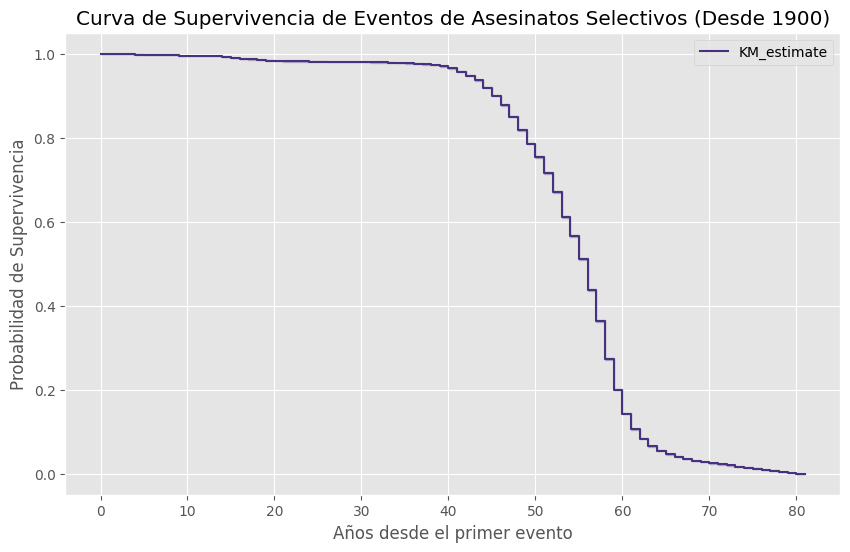

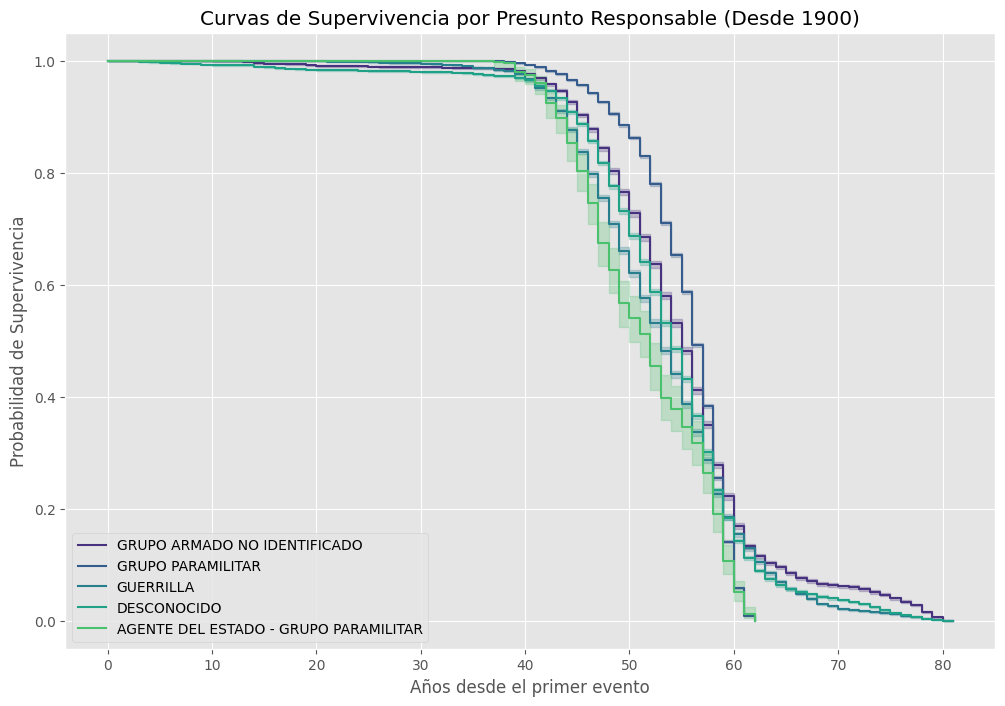

In [ ]:
!pip install lifelines

# 5. ANÁLISIS DE SUPERVIVENCIA (KAPLAN-MEIER)
print("\n11. Análisis de supervivencia (Kaplan-Meier)")

# Filter out years before 1900
df_filtered_survival = df_clean[df_clean['Año'] >= 1900].copy()

# Crear variable de "tiempo" (años desde el primer evento)
if 'Año' in df_filtered_survival.columns:
    min_year = df_filtered_survival['Año'].min()
    df_filtered_survival['Tiempo'] = df_filtered_survival['Año'] - min_year

    # Usar Kaplan-Meier para estimar la función de supervivencia
    # (considerando cada año como un "intervalo de tiempo")
    from lifelines import KaplanMeierFitter

    kmf = KaplanMeierFitter()

    # Para análisis de supervivencia, necesitaríamos saber si ocurrió el evento
    # En este caso, consideraremos cada registro como un evento
    kmf.fit(durations=df_filtered_survival['Tiempo'], event_observed=np.ones(len(df_filtered_survival)))

    plt.figure(figsize=(10, 6))
    kmf.plot()
    plt.title('Curva de Supervivencia de Eventos de Asesinatos Selectivos (Desde 1900)')
    plt.xlabel('Años desde el primer evento')
    plt.ylabel('Probabilidad de Supervivencia')
    plt.grid(True)
    plt.show()

    # Comparar supervivencia por grupos (ej. por presunto responsable)
    if 'Presunto Responsable' in df_filtered_survival.columns:
        plt.figure(figsize=(12, 8))
        ax = plt.subplot(111)

        for responsable in df_filtered_survival['Presunto Responsable'].unique()[:5]:  # Limitar a 5 grupos para claridad
            mask = df_filtered_survival['Presunto Responsable'] == responsable
            kmf.fit(durations=df_filtered_survival.loc[mask, 'Tiempo'],
                    event_observed=np.ones(mask.sum()),
                    label=responsable)
            kmf.plot(ax=ax)

        plt.title('Curvas de Supervivencia por Presunto Responsable (Desde 1900)')
        plt.xlabel('Años desde el primer evento')
        plt.ylabel('Probabilidad de Supervivencia')
        plt.grid(True)
        plt.legend()
        plt.show()

In [ ]:
# 6. MODELO DE REGRESIÓN (EJ: POISSON GLM)
print("\n12. Modelo de regresión (Ej: Poisson GLM)")

# modelo Poisson
if 'Total de Víctimas del Caso' in df_clean.columns:
    # Preparar datos para el modelo
    glm_df = df_clean[['Año', 'Mes', 'Total de Víctimas del Caso']].copy()

    # Codificar variables categóricas si es necesario
    for col in ['Modalidad', 'Presunto Responsable', 'Departamento']:
        if col in df_clean.columns:
            glm_df[col] = df_clean[col]
            # Usar codificación one-hot para variables categóricas
            dummies = pd.get_dummies(glm_df[col], prefix=col, drop_first=True)
            glm_df = pd.concat([glm_df, dummies], axis=1)
            glm_df.drop(col, axis=1, inplace=True)

    glm_df = glm_df.dropna()

    # Convert boolean columns to integers
    for col in glm_df.columns:
        if glm_df[col].dtype == 'bool':
            glm_df[col] = glm_df[col].astype(int)

    # Ajustar modelo Poisson
    X_glm = glm_df.drop('Total de Víctimas del Caso', axis=1)
    y_glm = glm_df['Total de Víctimas del Caso']

    # Añadir término constante
    X_glm = sm.add_constant(X_glm)

    # Ajustar modelo Poisson
    poisson_model = sm.GLM(y_glm, X_glm, family=sm.families.Poisson())
    poisson_results = poisson_model.fit()

    print("Resultados del modelo Poisson:")
    print(poisson_results.summary())


12. Modelo de regresión (Ej: Poisson GLM)
Resultados del modelo Poisson:
                     Generalized Linear Model Regression Results                      
Dep. Variable:     Total de Víctimas del Caso   No. Observations:               157136
Model:                                    GLM   Df Residuals:                   157066
Model Family:                         Poisson   Df Model:                           69
Link Function:                            Log   Scale:                          1.0000
Method:                                  IRLS   Log-Likelihood:            -1.7541e+05
Date:                        Sun, 09 Nov 2025   Deviance:                       20700.
Time:                                18:47:45   Pearson chi2:                 2.60e+04
No. Iterations:                             4   Pseudo R-squ. (CS):            0.01206
Covariance Type:                    nonrobust                                         
                                                        

In [ ]:
from sklearn.neural_network import MLPClassifier, MLPRegressor

# a. Regresión con MLP
try:
    mlp_reg = MLPRegressor(hidden_layer_sizes=(50, 25), activation='relu',
                          random_state=42, max_iter=1000)
    mlp_reg.fit(X_train, y_train)
    y_pred_mlp = mlp_reg.predict(X_test)
    mse_mlp = mean_squared_error(y_test, y_pred_mlp)
    print(f"Error Cuadrático Medio con MLP: {mse_mlp:.3f}")

    # Comparar con Random Forest
    # Assuming 'mse' from the previous cell is available for comparison
    # If not, you might need to re-run the RF regression part or store mse
    print(f"MLP vs Random Forest: {mse_mlp:.3f} vs {mse:.3f}")

except Exception as e:
    print(f"Error en MLP para regresión: {e}")

# b. Clasificación con MLP
if 'Presunto Responsable_encoded' in pca_df.columns:
    try:
        mlp_clf = MLPClassifier(hidden_layer_sizes=(50, 25), activation='relu',
                               random_state=42, max_iter=1000)
        mlp_clf.fit(X_train, y_train)
        y_pred_mlp_clf = mlp_clf.predict(X_test)

        print("\nReporte de clasificación con MLP:")
        # Get the unique labels in y_test and map them back to original class names
        unique_labels = np.unique(y_test)
        # Ensure le is accessible, if not, re-initialize and fit on the full encoded column
        # If le is not in the current scope, you might need to re-run the cell where it was defined
        # or add its definition here (less ideal if used elsewhere). Assuming le is globally accessible.
        target_names_subset = [le.classes_[label] for label in unique_labels]
        print(classification_report(y_test, y_pred_mlp_clf, target_names=target_names_subset))

    except Exception as e:
        print(f"Error en MLP para clasificación: {e}")

Error Cuadrático Medio con MLP: 5.683
MLP vs Random Forest: 5.683 vs 0.218

Reporte de clasificación con MLP:
                                                                    precision    recall  f1-score   support

                                               ARMA CORTO PUNZANTE       0.09      0.00      0.01      1475
                               ARMA CORTO PUNZANTE - ARMA DE FUEGO       0.00      0.00      0.00       168
         ARMA CORTO PUNZANTE - ARMA DE FUEGO - ARTEFACTO EXPLOSIVO       0.00      0.00      0.00         7
            ARMA CORTO PUNZANTE - ARMA DE FUEGO - ASFIXIA MEC NICA       0.00      0.00      0.00         3
        ARMA CORTO PUNZANTE - ARMA DE FUEGO - MATERIAL INCENDIARIO       0.45      0.20      0.28       492
                  ARMA CORTO PUNZANTE - ARMA DE FUEGO - MOTOSIERRA       0.00      0.00      0.00        44
          ARMA CORTO PUNZANTE - ARMA DE FUEGO - OBJETO CONTUNDENTE       0.00      0.00      0.00      9527
                        A

## Conclusiones Preliminares

### Conclusiones para Público No Especializado

Este análisis de los asesinatos selectivos en Colombia nos muestra varios puntos clave sobre el conflicto armado:

*   **La violencia ha tenido altibajos:** Hubo un período muy crítico a finales de los años 90 y principios de los 2000, donde se concentró la mayoría de estos hechos. Afortunadamente, después de eso, la violencia selectiva ha disminuido.
*   **Los paramilitares fueron los que más asesinatos selectivos cometieron:** Según los datos, este grupo fue el principal responsable de la mayoría de los casos y de las víctimas en total. Otros grupos armados también tuvieron participación importante.
*   **Hay lugares más afectados que otros:** La violencia no golpeó por igual a todo el país. Departamentos como Antioquia, Santander y Norte de Santander fueron los más afectados. Esto significa que para buscar soluciones, hay que poner especial atención en estas regiones.
*   **El tipo de arma importa y está relacionado con quién la usa:** Aunque el arma de fuego es muy común, hay ciertas armas o combinaciones de ellas que se asocian más a unos grupos armados que a otros.
*   **Algunos grupos son más propensos a matar a varias personas a la vez:** Los datos sugieren que ciertos actores armados tendieron a cometer asesinatos con más de una víctima a la vez.
*   **La "vida" de los eventos de violencia:** La forma en que los eventos de asesinatos selectivos han ocurrido a lo largo del tiempo muestra que su intensidad varía y que la probabilidad de que sigan sucediendo cambia según el momento histórico.

En resumen, entender cuándo, dónde y quién cometió estos asesinatos selectivos es fundamental para pensar en cómo construir la paz y evitar que la violencia se repita. Los patrones geográficos y temporales, junto con la identificación de los principales responsables, son puntos de partida clave para diseñar políticas públicas más efectivas.

### Conclusiones Técnicas

*   **Distribución temporal:** El análisis temporal muestra un pico significativo de asesinatos selectivos alrededor de finales de la década de 1990 y principios de la de 2000, con una disminución posterior (ver gráfico de evolución temporal).
*   **Responsables:** Los grupos paramilitares son responsables del mayor número de casos y víctimas, seguidos por grupos no identificados, la guerrilla y actores desconocidos (ver gráficos de distribución por presunto responsable).
*   **Concentración Geográfica:** Existe una alta concentración de casos y víctimas en ciertos departamentos, particularmente Antioquia, Santander y Norte de Santander, lo que sugiere la necesidad de enfoques regionales específicos (ver gráficos de distribución por departamento y coeficientes de Gini). El índice de Gini para casos (0.616) y víctimas (0.611) confirma esta concentración.
*   **Relación Arma-Responsable:** La prueba chi-cuadrado indica una relación significativa entre el tipo de arma utilizada y el presunto responsable (p < 0.05), aunque el mapa de calor normalizado por filas muestra que el "ARMA DE FUEGO" es prevalente en casi todos los grupos.
*   **Múltiples Víctimas:** La prueba chi-cuadrado revela una relación significativa entre los casos con múltiples víctimas y el tipo de actor armado (p < 0.05). Los "BANDOLERISMO", "AGENTE DEL ESTADO - GRUPO POSDESMOVILIZACIÓN" y "AGENTE DEL ESTADO" muestran una mayor proporción de casos con múltiples víctimas.
*   **Análisis de Supervivencia (Kaplan-Meier):** La curva general de supervivencia muestra una alta "mortalidad" de eventos en los años de mayor intensidad del conflicto. Las curvas por presunto responsable sugieren diferencias en el patrón temporal de los eventos según el grupo.
*   **Modelado Predictivo:**
    *   **Regresión (Random Forest):** El modelo de Random Forest tuvo un Error Cuadrático Medio bajo en la predicción del número de víctimas (MSE: 0.218), con el Año, Mes, Latitud y Longitud como las variables más importantes.
    *   **Clasificación (Random Forest y MLP):** Los modelos de clasificación para predecir el presunto responsable mostraron un desempeño moderado (Random Forest accuracy: 0.51, MLP accuracy: 0.42), lo que indica que predecir este atributo basándose en las variables disponibles es un desafío. Las variables temporales y espaciales (Año, Mes, Latitud, Longitud) fueron consistentemente importantes en ambos modelos.

#Entrega Final (entrenamiento)

##Clasificación

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

In [ ]:
print("definición del problema")

TARGET_VARIABLE = 'Presunto Responsable'

FEATURE_VARIABLES = [
    'Año', 'Mes', 'Día', 'Total de Víctimas del Caso',
    'Latitud', 'Longitud', 'Modalidad', 'Departamento',
    'Región', 'Tipo de Armas'
]

available_features = [f for f in FEATURE_VARIABLES if f in df.columns]
print(f"Variables predictoras disponibles: {available_features}")

definición del problema
Variables predictoras disponibles: ['Año', 'Mes', 'Día', 'Total de Víctimas del Caso', 'Latitud', 'Longitud', 'Modalidad', 'Departamento', 'Región', 'Tipo de Armas']


In [ ]:

print("Preprocesamiento de datos")

df_model = df[available_features + [TARGET_VARIABLE]].copy()

initial_size = len(df_model)
df_model = df_model.dropna(subset=[TARGET_VARIABLE])
print(f"Filas después de eliminar targets nulos: {len(df_model)}/{initial_size}")

numeric_features = df_model[available_features].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_model[available_features].select_dtypes(include=['object']).columns.tolist()

print(f"Variables numéricas: {numeric_features}")
print(f"Variables categóricas: {categorical_features}")

# Ver distribución del target
print(f"\nDistribución de la variable objetivo ({TARGET_VARIABLE}):")
target_distribution = df_model[TARGET_VARIABLE].value_counts()
print(target_distribution)

# muy pocas muestras
min_samples_per_class = 10  # Ajusta este valor según tu dataset
class_counts = df_model[TARGET_VARIABLE].value_counts()
valid_classes = class_counts[class_counts >= min_samples_per_class].index
df_model = df_model[df_model[TARGET_VARIABLE].isin(valid_classes)]

print(f"filas después de filtrar clases pequeñas: {len(df_model)}")

Preprocesamiento de datos
Filas después de eliminar targets nulos: 157136/157136
Variables numéricas: ['Año', 'Mes', 'Día', 'Total de Víctimas del Caso', 'Latitud', 'Longitud']
Variables categóricas: ['Modalidad', 'Departamento', 'Región', 'Tipo de Armas']

Distribución de la variable objetivo (Presunto Responsable):
Presunto Responsable
GRUPO PARAMILITAR                               65997
DESCONOCIDO                                     31756
GUERRILLA                                       24068
GRUPO ARMADO NO IDENTIFICADO                    22368
AGENTE DEL ESTADO                                4917
GRUPO POSDESMOVILIZACIÓN                         4130
BANDOLERISMO                                     1641
OTRO ¿CUÁL?                                      1515
AGENTE DEL ESTADO - GRUPO PARAMILITAR             559
CRIMEN ORGANIZADO                                 148
AGENTE DEL ESTADO - GRUPO POSDESMOVILIZACIÓN       24
AGENTE EXTRANJERO                                  11
GRUPO POSDES

In [ ]:

print("División de datos")

X = df_model[available_features]
y = df_model[TARGET_VARIABLE]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
    shuffle=True
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")
print(f"Distribución en entrenamiento:\n{y_train.value_counts()}")
print(f"Distribución en prueba:\n{y_test.value_counts()}")

División de datos
Conjunto de entrenamiento: 125707 muestras
Conjunto de prueba: 31427 muestras
Distribución en entrenamiento:
Presunto Responsable
GRUPO PARAMILITAR                               52798
DESCONOCIDO                                     25405
GUERRILLA                                       19254
GRUPO ARMADO NO IDENTIFICADO                    17894
AGENTE DEL ESTADO                                3934
GRUPO POSDESMOVILIZACIÓN                         3304
BANDOLERISMO                                     1313
OTRO ¿CUÁL?                                      1212
AGENTE DEL ESTADO - GRUPO PARAMILITAR             447
CRIMEN ORGANIZADO                                 118
AGENTE DEL ESTADO - GRUPO POSDESMOVILIZACIÓN       19
AGENTE EXTRANJERO                                   9
Name: count, dtype: int64
Distribución en prueba:
Presunto Responsable
GRUPO PARAMILITAR                               13199
DESCONOCIDO                                      6351
GUERRILLA                

In [ ]:
print("Creación del pipeline de preprocesamiento")


numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Creación del pipeline de preprocesamiento


In [ ]:
print("Definición de modelos")

models = {
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,  # Usar todos los cores
            class_weight='balanced'  # Manejar desbalanceo
        ))
    ]),

    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            random_state=42,
            n_jobs=-1,
            eval_metric='mlogloss',
            use_label_encoder=False
        ))
    ]),

    'LightGBM': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LGBMClassifier(
            random_state=42,
            n_jobs=-1,
            verbose=-1  # Silencioso
        ))
    ]),

    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            random_state=42,
            max_iter=1000,
            n_jobs=-1,
            class_weight='balanced'
        ))
    ])
}

Definición de modelos


In [ ]:
print("Entrenamiento y evaluación de modelos")

results = {}
confusion_matrices = {}
trained_models = {}

for name, pipeline in models.items():
    print(f"\n--- Entrenando {name} ---")

    try:
        # Entrenar modelo
        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)
        y_pred_proba = pipeline.predict_proba(X_test) if hasattr(pipeline, 'predict_proba') else None

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        # AUC-ROC
        auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted') if y_pred_proba is not None else 0

        # Guardar resultados
        results[name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'auc_roc': auc_roc,
            'pipeline': pipeline
        }

        # Guardar matriz de confusión
        confusion_matrices[name] = confusion_matrix(y_test, y_pred)
        trained_models[name] = pipeline

        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")
        if auc_roc > 0:
            print(f"AUC-ROC: {auc_roc:.4f}")

        # Validación cruzada
        print("Realizando validación cruzada...")
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3 folds para velocidad
        cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
        print(f"Validación cruzada (accuracy): {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

    except Exception as e:
        print(f"Error entrenando {name}: {e}")
        results[name] = None

Entrenamiento y evaluación de modelos

--- Entrenando Random Forest ---
Accuracy: 0.5044
Precision: 0.4726
Recall: 0.5044
F1-Score: 0.4770
AUC-ROC: 0.7379
Realizando validación cruzada...
Validación cruzada (accuracy): 0.5011 (+/- 0.0021)

--- Entrenando XGBoost ---
Error entrenando XGBoost: Invalid classes inferred from unique values of `y`.  Expected: [ 0  1  2  3  4  5  6  7  8  9 10 11], got ['AGENTE DEL ESTADO' 'AGENTE DEL ESTADO - GRUPO PARAMILITAR'
 'AGENTE DEL ESTADO - GRUPO POSDESMOVILIZACIÓN' 'AGENTE EXTRANJERO'
 'BANDOLERISMO' 'CRIMEN ORGANIZADO' 'DESCONOCIDO'
 'GRUPO ARMADO NO IDENTIFICADO' 'GRUPO PARAMILITAR'
 'GRUPO POSDESMOVILIZACIÓN' 'GUERRILLA' 'OTRO ¿CUÁL?']

--- Entrenando LightGBM ---
Accuracy: 0.5096
Precision: 0.4721
Recall: 0.5096
F1-Score: 0.4719
AUC-ROC: 0.7194
Realizando validación cruzada...
Validación cruzada (accuracy): 0.5106 (+/- 0.0086)

--- Entrenando Logistic Regression ---
Accuracy: 0.2173
Precision: 0.4120
Recall: 0.2173
F1-Score: 0.2522
AUC-ROC: 0.6

Comparación y selección del mejor modelo

Comparación de modelos:
                Modelo  Accuracy  Precision    Recall  F1-Score   AUC-ROC
2             LightGBM  0.509562   0.472118  0.509562  0.471868  0.719426
0        Random Forest  0.504375   0.472627  0.504375  0.476977  0.737903
3  Logistic Regression  0.217297   0.411962  0.217297  0.252160  0.650833
1              XGBoost  0.000000   0.000000  0.000000  0.000000  0.000000


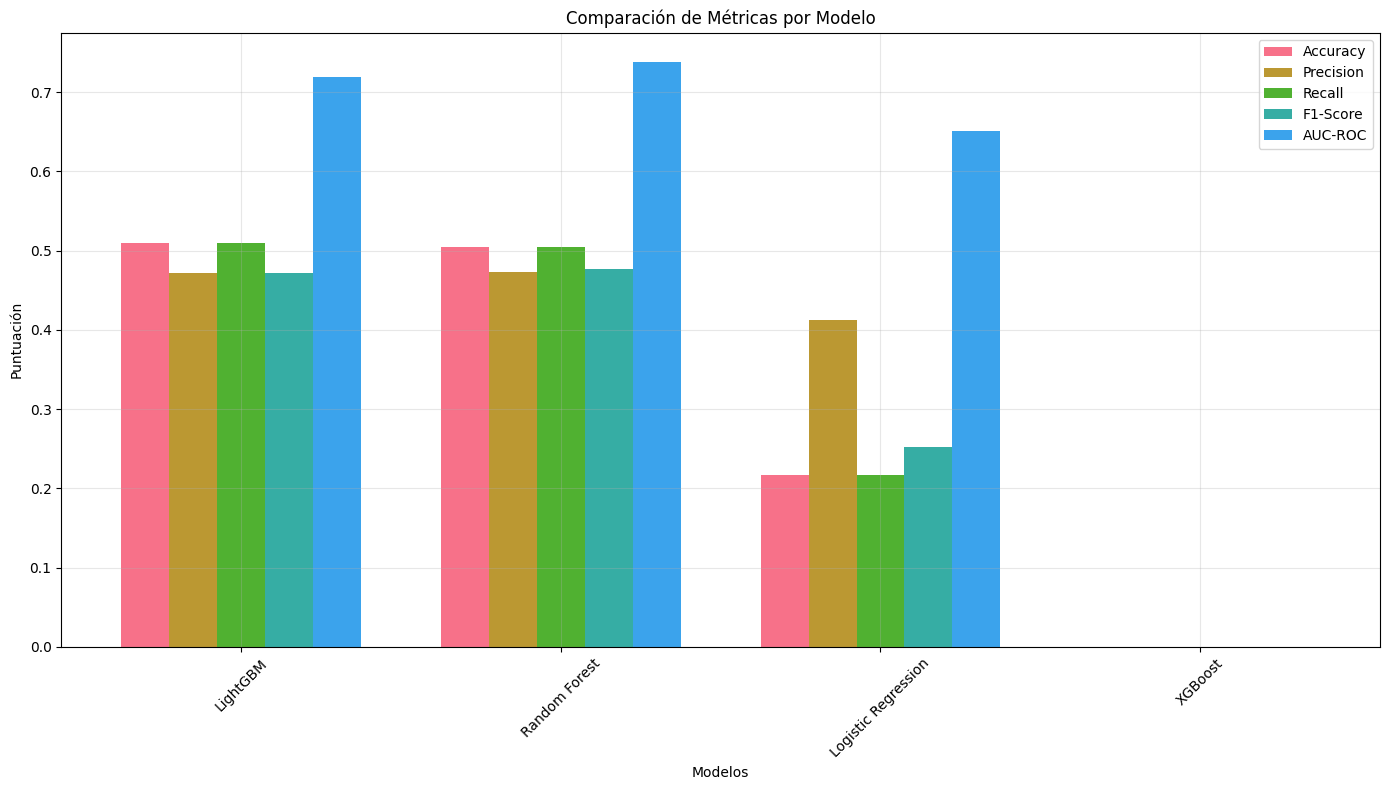

In [ ]:
print("Comparación y selección del mejor modelo")

results_df = pd.DataFrame({
    'Modelo': list(results.keys()),
    'Accuracy': [results[name]['accuracy'] if results[name] else 0 for name in results],
    'Precision': [results[name]['precision'] if results[name] else 0 for name in results],
    'Recall': [results[name]['recall'] if results[name] else 0 for name in results],
    'F1-Score': [results[name]['f1_score'] if results[name] else 0 for name in results],
    'AUC-ROC': [results[name]['auc_roc'] if results[name] else 0 for name in results]
}).sort_values('Accuracy', ascending=False)

print("\nComparación de modelos:")
print(results_df)

plt.figure(figsize=(14, 8))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x_pos = np.arange(len(results_df))

for i, metric in enumerate(metrics):
    if metric in results_df.columns:
        plt.bar(x_pos + i*0.15, results_df[metric], width=0.15, label=metric)

plt.xlabel('Modelos')
plt.ylabel('Puntuación')
plt.title('Comparación de Métricas por Modelo')
plt.xticks(x_pos + 0.3, results_df['Modelo'], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Análisis del mejor modelo
Mejor modelo: LightGBM
Accuracy: 0.5096


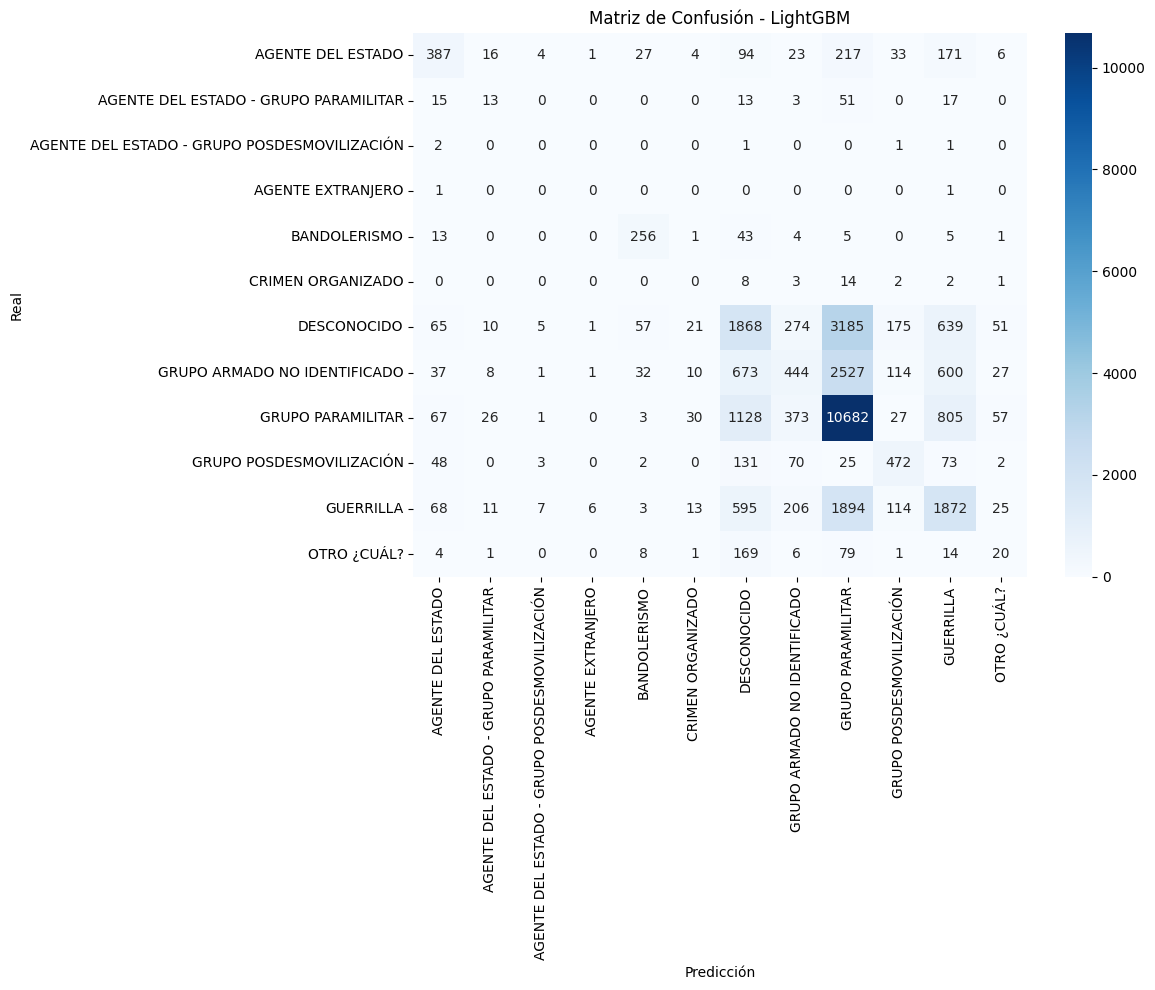


Reporte de clasificación detallado - LightGBM:
                                              precision    recall  f1-score   support

                           AGENTE DEL ESTADO       0.55      0.39      0.46       983
       AGENTE DEL ESTADO - GRUPO PARAMILITAR       0.15      0.12      0.13       112
AGENTE DEL ESTADO - GRUPO POSDESMOVILIZACIÓN       0.00      0.00      0.00         5
                           AGENTE EXTRANJERO       0.00      0.00      0.00         2
                                BANDOLERISMO       0.66      0.78      0.72       328
                           CRIMEN ORGANIZADO       0.00      0.00      0.00        30
                                 DESCONOCIDO       0.40      0.29      0.34      6351
                GRUPO ARMADO NO IDENTIFICADO       0.32      0.10      0.15      4474
                           GRUPO PARAMILITAR       0.57      0.81      0.67     13199
                    GRUPO POSDESMOVILIZACIÓN       0.50      0.57      0.53       826
     

In [ ]:
print("Análisis del mejor modelo")

best_model_name = results_df.iloc[0]['Modelo']
best_pipeline = trained_models[best_model_name]

print(f"Mejor modelo: {best_model_name}")
print(f"Accuracy: {results[best_model_name]['accuracy']:.4f}")

y_pred_best = best_pipeline.predict(X_test)
best_conf_matrix = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(12, 10))
sns.heatmap(best_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

print(f"\nReporte de clasificación detallado - {best_model_name}:")
print(classification_report(y_test, y_pred_best))

In [ ]:
print("Importancia de variables")

try:
    classifier = best_pipeline.named_steps['classifier']

    if hasattr(classifier, 'feature_importances_'):
        # Obtener nombres de características
        preprocessor = best_pipeline.named_steps['preprocessor']
        feature_names = []

        feature_names.extend(numeric_features)


        if categorical_features:
            ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
            cat_feature_names = ohe.get_feature_names_out(categorical_features)
            feature_names.extend(cat_feature_names)


        importances = classifier.feature_importances_


        plt.figure(figsize=(12, 8))
        sns.barplot(data=feature_importance_df.head(15), x='importance', y='feature')
        plt.title(f'Top 15 Variables Más Importantes - {best_model_name}')
        plt.xlabel('Importancia')
        plt.tight_layout()
        plt.show()

        print("\nTop 10 variables más importantes:")
        print(feature_importance_df.head(10))

except Exception as e:
    print(f"No se pudo obtener la importancia de variables: {e}")

Importancia de variables
No se pudo obtener la importancia de variables: name 'feature_importance_df' is not defined


<Figure size 1200x800 with 0 Axes>

In [ ]:
print("Optimización de hiperparámetros")

OPTIMIZE = True

if OPTIMIZE and best_model_name == 'Random Forest':
    print("Optimizando Random Forest...")

    param_grid = {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [None, 10, 20],
        'classifier__min_samples_split': [2, 5],
        'classifier__min_samples_leaf': [1, 2]
    }

    grid_search = GridSearchCV(
        best_pipeline,
        param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    print(f"Mejores parámetros: {grid_search.best_params_}")
    print(f"Mejor score: {grid_search.best_score_:.4f}")

    # Usar
    best_pipeline_optimized = grid_search.best_estimator_
    y_pred_optimized = best_pipeline_optimized.predict(X_test)

    print(f"Accuracy con modelo optimizado: {accuracy_score(y_test, y_pred_optimized):.4f}")

Optimización de hiperparámetros


In [ ]:
print("Guardar modelo y metadatas")

model_artifacts = {
    'model': best_pipeline,
    'feature_columns': available_features,
    'target_variable': TARGET_VARIABLE,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'results': results_df,
    'training_date': pd.Timestamp.now()
}

joblib.dump(model_artifacts, 'mejor_modelo_clasificacion_completo.pkl')
print("Modelo guardado como 'mejor_modelo_clasificacion_completo.pkl'")

Guardar modelo y metadatas
Modelo guardado como 'mejor_modelo_clasificacion_completo.pkl'


##Regresión

In [66]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

# Variable objetivo
TARGET_REGRESSION = 'Total de Víctimas del Caso'

REGRESSION_FEATURES = [
    'Año', 'Mes', 'Total de Víctimas del Caso',
    'Modalidad', 'Presunto Responsable', 'Departamento'
]

# Filtrar variables disponibles
available_reg_features = [f for f in REGRESSION_FEATURES if f in df.columns and f != TARGET_REGRESSION]
print(f"Variables predictoras seleccionadas: {available_reg_features}")

Variables predictoras seleccionadas: ['Año', 'Mes', 'Modalidad', 'Presunto Responsable', 'Departamento']


In [67]:
print("Preparación de datos optimizada")

# Crear dataset reducido
df_reg = df[available_reg_features + [TARGET_REGRESSION]].copy()

# Eliminar filas con target nulo y muestrear si es muy grande
df_reg = df_reg.dropna(subset=[TARGET_REGRESSION])

if len(df_reg) > 10000:
    df_reg = df_reg.sample(n=10000, random_state=42)
    print(f"Dataset muestreado a 10,000 filas para eficiencia")

print(f"Tamaño final del dataset: {len(df_reg)} filas")

numeric_features_reg = df_reg[available_reg_features].select_dtypes(include=[np.number]).columns.tolist()
categorical_features_reg = df_reg[available_reg_features].select_dtypes(include=['object']).columns.tolist()

print(f"Variables numéricas: {numeric_features_reg}")
print(f"Variables categóricas: {categorical_features_reg}")

Preparación de datos optimizada
Dataset muestreado a 10,000 filas para eficiencia
Tamaño final del dataset: 10000 filas
Variables numéricas: ['Año', 'Mes']
Variables categóricas: ['Modalidad', 'Presunto Responsable', 'Departamento']


In [68]:
print("División de datos")

X_reg = df_reg[available_reg_features]
y_reg = df_reg[TARGET_REGRESSION]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

print(f"Entrenamiento: {X_train_reg.shape[0]}, Prueba: {X_test_reg.shape[0]}")


División de datos
Entrenamiento: 8000, Prueba: 2000


In [69]:
print("Pipeline simplificado")

# Preprocesadores básicos
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# OneHotEncoder con max_categories para limitar dimensiones
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=20))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_reg),
        ('cat', categorical_transformer, categorical_features_reg)
    ]
)

Pipeline simplificado


In [70]:
print("Modelos optimizados")

regression_models = {
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(
            n_estimators=50,
            max_depth=10,
            random_state=42,
            n_jobs=1
        ))
    ]),

    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', XGBRegressor(
            n_estimators=50,  # Reducido
            max_depth=6,      # Limitado
            random_state=42,
            n_jobs=1,
            objective='reg:squarederror'
        ))
    ]),

    'Ridge': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Ridge(random_state=42))
    ]),

    'Lasso': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Lasso(random_state=42, alpha=0.1))
    ])
}

Modelos optimizados


In [71]:
print("Validación cruzada optimizada")

kfold = KFold(n_splits=3, shuffle=True, random_state=42)
cv_results = {}

print("Evaluando modelos (esto puede tomar unos minutos)...")

for name, pipeline in regression_models.items():
    print(f"\n--- {name} ---")

    try:
        # Entrenar modelo
        pipeline.fit(X_train_reg, y_train_reg)

        # Predicciones simples
        y_pred = pipeline.predict(X_test_reg)

        # Métricas básicas
        test_metrics = {
            'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred)),
            'MAE': mean_absolute_error(y_test_reg, y_pred),
            'R2': r2_score(y_test_reg, y_pred)
        }

        # Validación cruzada solo con R2 para ahorrar tiempo
        cv_r2_scores = cross_val_score(pipeline, X_train_reg, y_train_reg,
                                     cv=kfold, scoring='r2', n_jobs=1)

        cv_results[name] = {
            'test_metrics': test_metrics,
            'cv_r2_mean': cv_r2_scores.mean(),
            'cv_r2_std': cv_r2_scores.std(),
            'pipeline': pipeline
        }

        print(f"R² CV: {cv_r2_scores.mean():.4f} (+/- {cv_r2_scores.std() * 2:.4f})")
        print(f"R² Test: {test_metrics['R2']:.4f}")
        print(f"RMSE Test: {test_metrics['RMSE']:.4f}")

    except Exception as e:
        print(f"Error en {name}: {e}")
        cv_results[name] = None

Validación cruzada optimizada
Evaluando modelos (esto puede tomar unos minutos)...

--- Random Forest ---
R² CV: 0.0476 (+/- 0.0236)
R² Test: 0.0405
RMSE Test: 0.4564

--- XGBoost ---
R² CV: -0.0115 (+/- 0.0428)
R² Test: -0.0163
RMSE Test: 0.4697

--- Ridge ---
R² CV: 0.0510 (+/- 0.0247)
R² Test: 0.0706
RMSE Test: 0.4491

--- Lasso ---
R² CV: -0.0007 (+/- 0.0010)
R² Test: -0.0000
RMSE Test: 0.4659


Comparación de modelos

Resultados comparativos:
          Modelo  CV_R2_Mean  CV_R2_Std  Test_R2  Test_RMSE  Test_MAE
2          Ridge      0.0510     0.0124   0.0706     0.4491    0.2838
0  Random Forest      0.0476     0.0118   0.0405     0.4564    0.2845
3          Lasso     -0.0007     0.0005  -0.0000     0.4659    0.3016
1        XGBoost     -0.0115     0.0214  -0.0163     0.4697    0.2874


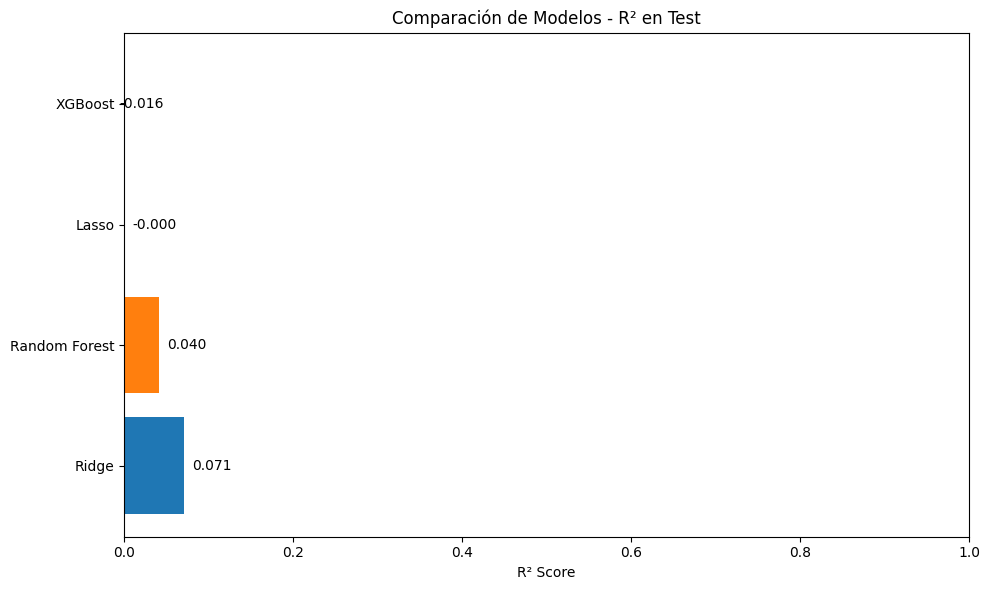

In [72]:
print("Comparación de modelos")

comparison_data = []
for model_name, results in cv_results.items():
    if results is not None:
        comparison_data.append({
            'Modelo': model_name,
            'CV_R2_Mean': results['cv_r2_mean'],
            'CV_R2_Std': results['cv_r2_std'],
            'Test_R2': results['test_metrics']['R2'],
            'Test_RMSE': results['test_metrics']['RMSE'],
            'Test_MAE': results['test_metrics']['MAE']
        })

comparison_df = pd.DataFrame(comparison_data).sort_values('Test_R2', ascending=False)

print("\nResultados comparativos:")
print(comparison_df.round(4))

# Visualización mínima pero efectiva
plt.figure(figsize=(10, 6))
models = comparison_df['Modelo']
r2_scores = comparison_df['Test_R2']

plt.barh(models, r2_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.xlabel('R² Score')
plt.title('Comparación de Modelos - R² en Test')
plt.xlim(0, 1)
for i, v in enumerate(r2_scores):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

Análisis del mejor modelo
Mejor modelo: Ridge
R²: 0.0706
RMSE: 0.4491


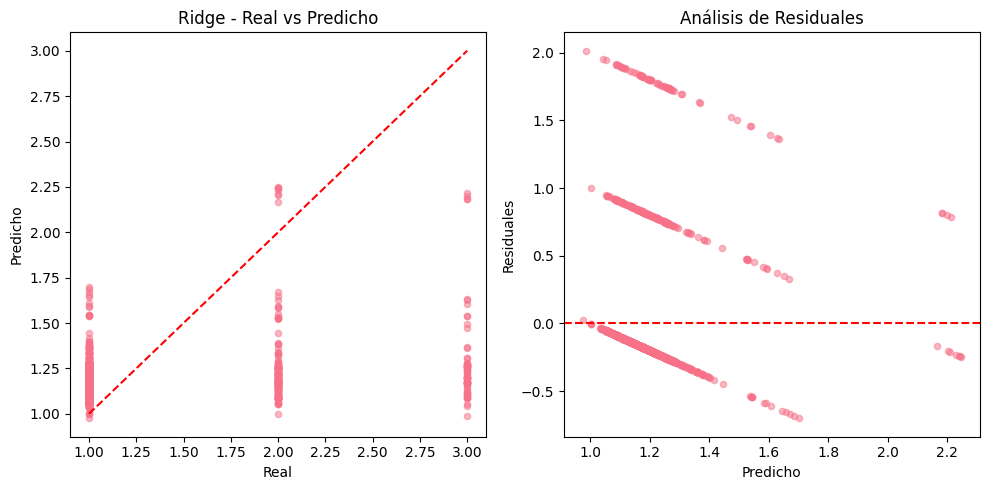

In [74]:
print("Análisis del mejor modelo")

best_model_name = comparison_df.iloc[0]['Modelo']
best_pipeline = cv_results[best_model_name]['pipeline']

print(f"Mejor modelo: {best_model_name}")
print(f"R²: {comparison_df.iloc[0]['Test_R2']:.4f}")
print(f"RMSE: {comparison_df.iloc[0]['Test_RMSE']:.4f}")

# Gráfico simple de predicciones vs reales
y_pred_best = best_pipeline.predict(X_test_reg)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test_reg, y_pred_best, alpha=0.5, s=20)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title(f'{best_model_name} - Real vs Predicho')

plt.subplot(1, 2, 2)
residuals = y_test_reg - y_pred_best
plt.scatter(y_pred_best, residuals, alpha=0.5, s=20)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicho')
plt.ylabel('Residuales')
plt.title('Análisis de Residuales')

plt.tight_layout()
plt.show()

In [75]:
print("Importancia de variables")

try:
    regressor = best_pipeline.named_steps['regressor']

    if hasattr(regressor, 'feature_importances_'):
        # Obtener nombres de características
        preprocessor = best_pipeline.named_steps['preprocessor']

        # Solo mostrar importancia si el modelo la soporta
        if best_model_name in ['Random Forest', 'XGBoost']:
            feature_names = numeric_features_reg.copy()

            if categorical_features_reg:
                ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
                cat_features = ohe.get_feature_names_out(categorical_features_reg)
                feature_names.extend(cat_features)

            importances = regressor.feature_importances_

            # Top 10 características
            importance_df = pd.DataFrame({
                'feature': feature_names,
                'importance': importances
            }).sort_values('importance', ascending=False).head(10)

            plt.figure(figsize=(10, 6))
            sns.barplot(data=importance_df, x='importance', y='feature')
            plt.title(f'Top 10 Variables - {best_model_name}')
            plt.tight_layout()
            plt.show()

            print("Variables más importantes:")
            print(importance_df)

except Exception as e:
    print(f"Importancia no disponible: {e}")

Importancia de variables


In [76]:
print("Guardado del modelo")

# Crear artefactos livianos
regression_artifacts = {
    'model': best_pipeline,
    'feature_columns': available_reg_features,
    'target_variable': TARGET_REGRESSION,
    'best_model_name': best_model_name,
    'performance': {
        'R2': comparison_df.iloc[0]['Test_R2'],
        'RMSE': comparison_df.iloc[0]['Test_RMSE']
    }
}

joblib.dump(regression_artifacts, 'modelo_regresion_optimizado.pkl')
print("Modelo guardado como 'modelo_regresion_optimizado.pkl'")

# Guardar resultados
comparison_df.to_csv('resultados_regresion_optimizados.csv', index=False)
print("Resultados guardados en 'resultados_regresion_optimizados.csv'")

Guardado del modelo
Modelo guardado como 'modelo_regresion_optimizado.pkl'
Resultados guardados en 'resultados_regresion_optimizados.csv'


In [77]:
print(f"Dataset procesado: {len(df_reg)} filas")
print(f"Modelos evaluados: {len(regression_models)}")
print(f"Mejor modelo: {best_model_name}")
print(f"R² alcanzado: {comparison_df.iloc[0]['Test_R2']:.4f}")
print(f"Archivos generados: 2")

print(f"Interpretación:")
r2_score = comparison_df.iloc[0]['Test_R2']
if r2_score > 0.7:
    print("   Excelente poder predictivo")
elif r2_score > 0.5:
    print("   Buen poder predictivo")
elif r2_score > 0.3:
    print("   Poder predictivo moderado")
else:
    print("   Poder predictivo limitado")

Dataset procesado: 10000 filas
Modelos evaluados: 4
Mejor modelo: Ridge
R² alcanzado: 0.0706
Archivos generados: 2
Interpretación:
   Poder predictivo limitado
